# Seed–Refine–Snap: LiDAR Building Footprint Extraction

## Pipeline Overview

Every building goes through three stages:

```
Raw LiDAR points
      │
      ▼
  [Stage 1] SEED  ─── alpha-shape hull sampled to N=150 points
      │               No learning — purely geometric
      │
      ▼
  [Stage 2] REFINE ── lightweight CNN predicts per-point displacement
      │               Moves each hull point toward the GT boundary
      │               Input: 4 local geometry features per point
      │
      ▼
  [Stage 3] SNAP  ─── rule-based geometric regularizer
                      Snaps near-axis walls to dominant orientation
                      Cleans up noisy edges without distorting area
```

**Key questions the ablations answer:**

| Question | Experiment |
|----------|-----------|
| Does the CNN actually help over raw seed? | A1 (seed) vs A2 (seed+CNN) |
| Does snap help? | A2 (no snap) vs F0 (full, with snap) |
| Can we skip CNN and just snap the seed? | A6 (seed+snap, no CNN) vs F0 |
| Is CNN + snap together what matters? | Compare A6, A2, F0 directly |
| Does global CNN context help vs local? | A4 vs F0 |
| Does global target frame matter? | A3 vs F0 |
| Does a regularity training loss help? | A5 vs F0 |
| Which input features matter most? | Feature ablation (F0, Drop-X, pairs) |

---

## Experiment Definitions

### Component Ablations (A1–A6)

| ID | Name | Seed | CNN | Snap | Purpose |
|----|------|------|-----|------|---------|
| A1 | Seed Only | ✓ | ✗ | ✗ | Baseline: raw hull, no learning |
| A2 | CNN, No Snap | ✓ | ✓ | ✗ | Does snap add anything on top of CNN? |
| A3 | Global XY Targets | ✓ | ✓ | ✓ | Local vs global coordinate frame for targets |
| A4 | Global-Context CNN | ✓ | ✓(global) | ✓ | Local vs global pooling in network |
| A5 | Regularity Loss | ✓ | ✓ | ✓ | Does a geometry-aware training loss help? |
| **A6** | **Seed + Snap, No CNN** | ✓ | ✗ | ✓ | **Does CNN help, or does snap alone suffice?** |

### Feature Ablations (F0 = full model)

Uses the full pipeline (Seed → CNN → Snap). Tests which of 4 input feature groups matter:
- `chord_dev` — deviation from chord line (corner detector)
- `linearity` — PCA linearity of nearby raw points (wall vs corner)
- `density` — point count in local radius (coverage quality)
- `signal_prior` — peak-detection on curvature signal (likely corners)

Experiments: Full, Drop-one (×4), All pairwise combinations (×6) = **11 total**.


In [1]:
# ==========================================
# CUSTOM PATH CONFIGURATION
# Set your absolute base directory here.
# For publication/others, this can be f"{BASE_DIR}/"
# ==========================================
import os
BASE_DIR = "/mnt/d/Saqib/Footprint_Extraction/DIF/Code"

import os, pickle, warnings, itertools, random, math, time
import json
import numpy as np
import pandas as pd
import laspy
import geopandas as gpd
from tqdm import tqdm
from scipy.spatial import Delaunay, cKDTree
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks
from shapely.geometry import MultiLineString, Polygon, Point, LinearRing
from shapely.ops import polygonize
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
matplotlib.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 120,
})
CFG = dict(
    # Raw data directories
    train_data_dir = r"D:\Saqib\Footprint_Extraction\GroundTruth\refine_files_building_extraction_pipeline\matched_buildings_C_34GN1",
    val_data_dir   = r"D:\Saqib\Footprint_Extraction\GroundTruth\refine_files_building_extraction_pipeline\matched_buildings_21FZ1_01",
    test_data_dir  = r"D:\Saqib\Footprint_Extraction\GroundTruth\refine_files_building_extraction_pipeline\matched_buildings_66FN2_11",
    # Core preprocessing/training settings
    point_count   = 150,
    batch_size    = 32,
    lr            = 1e-3,
    epochs        = 60,
    weight_decay  = 1e-4,
    patience      = 12,
    # Model
    base_ch       = 64,
    n_blocks      = 4,
    kernel        = 5,
    dropout       = 0.10,
    # Evaluation / inference
    device        = "cuda" if torch.cuda.is_available() else "cpu",
)
def _auto_out(d):
    return d.rstrip("\\/") + "_seed_refine_snap_custom"
# All generated PKLs and artifacts live under the shared outputs folder.
# The notebook creates dataset-specific subfolders inside this project directory.
OUTPUT_ROOT = r"D:\Saqib\Footprint_Extraction\DIF\Code\outputs"
PROJECT_DIR = os.path.join(OUTPUT_ROOT, "seed_refine_snap_v9_with_vaihingen")
PKL_ROOT    = os.path.join(PROJECT_DIR, "pkls")
CFG["train_out_dir"] = os.path.join(PKL_ROOT, "ahn_train")
CFG["val_out_dir"]   = os.path.join(PKL_ROOT, "ahn_val")
CFG["test_out_dir"]  = os.path.join(PKL_ROOT, "ahn_test")
OUTPUT_DIR = PROJECT_DIR
CKPT_DIR   = os.path.join(OUTPUT_DIR, "checkpoints")
SAMPLE_DIR = os.path.join(OUTPUT_DIR, "sample_predictions")
EVAL_SAMPLE_DIR = os.path.join(OUTPUT_DIR, "eval_sample_predictions")
for d in [
    OUTPUT_ROOT,
    OUTPUT_DIR,
    PKL_ROOT,
    CFG["train_out_dir"],
    CFG["val_out_dir"],
    CFG["test_out_dir"],
    CKPT_DIR,
    SAMPLE_DIR,
    EVAL_SAMPLE_DIR,
]:
    os.makedirs(d, exist_ok=True)
N_SAMPLE    = 512
RANDOM_SEED = 42
N_EPOCHS    = 100
BATCH_SIZE  = 128
LR          = 0.001
VAL_EVERY   = 20
PATIENCE    = 5
LAMBDA_REG  = 2.5
DEVICE      = CFG["device"]
# REG_CFG = dict(
#     dp_tolerance=0.2,
#     corner_thresh_deg=25.0,
#     min_wall_pts=2,
#     area_tol=0.15,
#     snap_tol_deg=10.0,
#     curve_var_thresh=0.01,
# )
REG_CFG = dict(
    dp_tolerance=0.45,
    corner_thresh_deg=25.0,
    min_wall_pts=5,
    area_tol=0.15,
    snap_tol_deg=10.0,
    curve_var_thresh=0.01,
)
# Separate dataset configs are declared explicitly here.
# These configs are the source of truth and are never overwritten by
# dataset profiling / metadata estimation later in the notebook.
AHN_GEOMETRY_CFG = dict(
    dataset_name="AHN",
    display_name="AHN (Actueel Hoogtebestand Nederland)",
    expected_density_range=(10.0, 20.0),
    expected_spacing_m=0.37,
    alpha_factor=0.82,
    alpha_k=8,
    alpha=0.82 / 0.37,
    chord_stride=3,
    lin_radius=0.37,
    den_radius=0.37,
    sp_sigma=2.5,
    sp_height=0.20,
    sp_distance=8,
    point_count=CFG["point_count"],
    reg_cfg=dict(REG_CFG),
)
# VAIHINGEN_GEOMETRY_CFG = dict(
#     dataset_name="VAIHINGEN",
#     display_name="ISPRS Vaihingen 3D Benchmark",
#     expected_density_range=(4.0, 8.0),
#     expected_spacing_m=0.50,
#     alpha_factor=0.60,
#     alpha_k=8,
#     alpha=0.6 / 0.50,
#     chord_stride=3,
#     lin_radius=0.3,
#     den_radius=0.3,
#     sp_sigma=2.5,
#     sp_height=0.15,
#     sp_distance=8,
#     point_count=CFG["point_count"],
#     reg_cfg=dict(REG_CFG),
# )
VAIHINGEN_GEOMETRY_CFG = dict(
    dataset_name="VAIHINGEN",
    display_name="ISPRS Vaihingen 3D Benchmark",
    expected_density_range=(4.0, 8.0),
    expected_spacing_m=0.50,
    alpha_factor=0.55,
    alpha_k=9,
    alpha=0.55 / 0.50,
    chord_stride=3,
    lin_radius=0.3,
    den_radius=0.3,
    sp_sigma=2.5,
    sp_height=0.15,
    sp_distance=8,
    point_count=CFG["point_count"],
    reg_cfg=dict(REG_CFG),
)
DATASET_CFGS = {
    "AHN": AHN_GEOMETRY_CFG,
    "VAIHINGEN": VAIHINGEN_GEOMETRY_CFG,
}
# Global ablation switches.
# Set any entry to False to skip training/testing for that ablation.
# F0 is mandatory because it is the reference model used in the final
# stage-wise tables and cross-dataset summaries.
ABLATION_RUNS = {
    "feature": {
        "F0 — Full (all groups)": True,
        "Drop chord_dev": True,
        "Drop linearity": True,
        "Drop density": True,
        "Drop signal_prior": True,
        "chord_dev + linearity": True,
        "chord_dev + density": True,
        "chord_dev + signal_prior": True,
        "linearity + density": True,
        "linearity + signal_prior": True,
        "density + signal_prior": True,
    },
    "component": {
        "seed_only": True,
        "no_snap": True,
        "global_targets": True,
        "global_model": True,
        "with_regloss": True,
        "seed_snap": True,
    },
}
MANDATORY_ABLATIONS = {
    "feature": {"F0 — Full (all groups)"},
    "component": set(),
}
def _ablation_enabled(kind, name):
    if kind in MANDATORY_ABLATIONS and name in MANDATORY_ABLATIONS[kind]:
        return True
    return bool(ABLATION_RUNS.get(kind, {}).get(name, True))
C_RAW = "#E74C3C"
C_GT = "#2ECC71"
C_SEED = "#2980B9"
C_REF = "#1A1A1A"
C_SNAP = "#8E44AD"
print("Imports OK | torch", torch.__version__, "| device:", DEVICE)
print("Train PKL dir:", CFG["train_out_dir"])
print("Val   PKL dir:", CFG["val_out_dir"])
print("Test  PKL dir:", CFG["test_out_dir"])
print("Vaihingen PKL :", os.path.join(PKL_ROOT, "vaihingen_test"))
print("Output dir   :", OUTPUT_DIR)

Imports OK | torch 2.7.1+cu118 | device: cuda
Train PKL dir: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_train
Val   PKL dir: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_val
Test  PKL dir: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_test
Vaihingen PKL : D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\vaihingen_test
Output dir   : D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen


## Dataset metadata and geometry settings

AHN and Vaihingen keep separate manually declared geometry configs.  
The notebook may still compute a small dataset profile for reporting, but that profile is never allowed to overwrite any declared parameter.  
`REG_CFG` stays shared across both datasets.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET PROFILE + GEOMETRY HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def _dataset_key(name):
    if name is None:
        return "AHN"
    key = str(name).strip().upper().replace(" ", "_")
    if "VAIH" in key:
        return "VAIHINGEN"
    if "AHN" in key:
        return "AHN"
    return key
def estimate_nn_spacing(pts, k=8):
    pts = np.asarray(pts, dtype=np.float64)
    if len(pts) < 3:
        return float("nan")
    k = int(max(1, min(k, len(pts) - 1)))
    d = cKDTree(pts).query(pts, k=k + 1)[0][:, 1:]
    return float(np.mean(d))
def estimate_point_density(pts, area=None):
    pts = np.asarray(pts, dtype=np.float64)
    if area is None:
        if len(pts) < 3:
            return float("nan")
        area = float(Polygon(pts).convex_hull.area)
    if area is None or area <= 1e-12:
        return float("nan")
    return float(len(pts) / area)
def summarize_dataset_profile(data_dir, sample_limit=24, spacing_k=8):
    """
    Lightweight dataset profiler computed from the cached LAS/SHP pairs.
    The resulting profile is for inspection/reporting only. It does not
    overwrite any declared geometry parameter.
    """
    las_files = sorted(f for f in os.listdir(data_dir) if f.lower().endswith(".las"))[:sample_limit]
    rows = []
    for las_file in las_files:
        base = os.path.splitext(las_file)[0]
        shp_p = os.path.join(data_dir, base + ".shp")
        las_p = os.path.join(data_dir, las_file)
        if not os.path.exists(shp_p):
            continue
        try:
            las = laspy.read(las_p)
            raw = np.vstack((las.x, las.y)).T.astype(np.float64)
            gdf = gpd.read_file(shp_p)
            gt_poly = gdf.geometry.iloc[0]
            gt = np.array(gt_poly.exterior.coords)[:-1].astype(np.float64)
            ctr = np.array([gt_poly.centroid.x, gt_poly.centroid.y], dtype=np.float64)
            raw0 = raw - ctr
            gt0 = gt - ctr
            spacing = estimate_nn_spacing(raw0, k=spacing_k)
            density = estimate_point_density(raw0, area=abs(Polygon(gt0).area))
            perimeter = float(Polygon(gt0).length)
            rows.append({
                "building_id": base,
                "n_points": len(raw0),
                "median_nn_spacing": spacing,
                "estimated_density": density,
                "gt_perimeter": perimeter,
                "gt_area": float(abs(Polygon(gt0).area)),
            })
        except Exception:
            continue
    if not rows:
        return {
            "n_buildings": 0,
            "sample_limit": sample_limit,
            "median_nn_spacing": float("nan"),
            "median_density": float("nan"),
            "median_points": float("nan"),
            "median_perimeter": float("nan"),
            "spacing_cv": float("nan"),
        }, pd.DataFrame()
    df = pd.DataFrame(rows)
    spacing = df["median_nn_spacing"].replace([np.inf, -np.inf], np.nan).dropna()
    density = df["estimated_density"].replace([np.inf, -np.inf], np.nan).dropna()
    perim = df["gt_perimeter"].replace([np.inf, -np.inf], np.nan).dropna()
    profile = {
        "n_buildings": int(len(df)),
        "sample_limit": int(sample_limit),
        "median_nn_spacing": float(spacing.median()) if len(spacing) else float("nan"),
        "median_density": float(density.median()) if len(density) else float("nan"),
        "median_points": float(df["n_points"].median()) if len(df) else float("nan"),
        "median_perimeter": float(perim.median()) if len(perim) else float("nan"),
        "spacing_cv": float(spacing.std() / max(spacing.mean(), 1e-12)) if len(spacing) else float("nan"),
    }
    return profile, df
def build_dataset_geometry_cfg(dataset_name, profile=None, point_count=None):
    key = _dataset_key(dataset_name)
    base = DATASET_CFGS.get(key, DATASET_CFGS["AHN"])
    profile = profile or {}
    cfg = dict(base)
    cfg["dataset_name"] = key
    cfg["point_count"] = int(point_count if point_count is not None else CFG["point_count"])
    cfg["profile"] = profile
    cfg["reg_cfg"] = dict(REG_CFG)
    return cfg
def print_dataset_profile(name, profile, geometry_cfg=None):
    geometry_cfg = geometry_cfg or build_dataset_geometry_cfg(name, profile=profile)
    lo, hi = geometry_cfg["expected_density_range"]
    print(f"\n[{geometry_cfg['dataset_name']}] {geometry_cfg['display_name']}")
    print(f"  sampled buildings : {profile.get('n_buildings', 'n/a')}")
    print(f"  median spacing    : {profile.get('median_nn_spacing', np.nan):.4f} m")
    print(f"  median density    : {profile.get('median_density', np.nan):.2f} pts/m²")
    if np.isfinite(lo) and np.isfinite(hi) and lo == hi:
        print(f"  literature density: {lo:.1f} pts/m²")
    else:
        print(f"  literature density: {lo:.1f}–{hi:.1f} pts/m²")
    print(f"  alpha             : {geometry_cfg['alpha']:.4f}")
    print(f"  chord stride      : {geometry_cfg['chord_stride']}")
    print(f"  lin / den radius  : {geometry_cfg['lin_radius']:.3f} / {geometry_cfg['den_radius']:.3f} m")
    print(f"  snap tolerance    : {geometry_cfg['reg_cfg']['snap_tol_deg']:.1f}°")
    return geometry_cfg
print("Dataset geometry helpers ready.")

Dataset geometry helpers ready.


## Stage 1 — Seed Generation & Feature Extraction

Builds the initial polygon (seed) from raw LiDAR using an alpha-shape, samples it to N uniformly-spaced points,
then computes 4 local geometry features at each point. These features are the CNN's input.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# GEOMETRY + FEATURE FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def compute_tangent_angles(pts):
    d = np.roll(pts, -1, axis=0) - np.roll(pts, 1, axis=0)
    return np.arctan2(d[:, 1], d[:, 0]).astype(np.float32)
def estimate_alpha(pts, k=8, alpha_factor=0.80, spacing=None, return_spacing=False):
    """
    Alpha is estimated from local point spacing.
    Smaller spacing -> larger alpha -> tighter hull.
    """
    if spacing is None:
        spacing = estimate_nn_spacing(pts, k=k)
    if not np.isfinite(spacing) or spacing <= 1e-12:
        spacing = 1.0
    alpha = float(alpha_factor / spacing)
    return (alpha, float(spacing)) if return_spacing else alpha
def alpha_shape(pts, alpha):
    tri = Delaunay(pts)
    s = tri.simplices
    pa, pb, pc = pts[s[:, 0]], pts[s[:, 1]], pts[s[:, 2]]
    a = np.linalg.norm(pb - pa, axis=1)
    b = np.linalg.norm(pc - pb, axis=1)
    c = np.linalg.norm(pa - pc, axis=1)
    sp = (a + b + c) / 2
    area = np.maximum(sp * (sp - a) * (sp - b) * (sp - c), 0.0)
    with np.errstate(divide="ignore", invalid="ignore"):
        cr = np.where(area > 0, a * b * c / (4 * np.sqrt(np.maximum(area, 1e-20))), np.inf)
    keep = s[cr < 1.0 / alpha]
    if len(keep) == 0:
        return None
    all_edges = np.sort(np.vstack([keep[:, [0, 1]], keep[:, [1, 2]], keep[:, [2, 0]]]), axis=1)
    ev = np.ascontiguousarray(all_edges).view(np.dtype((np.void, all_edges.dtype.itemsize * 2))).ravel()
    uniq, cnt = np.unique(ev, return_counts=True)
    boundary = uniq[cnt == 1].view(np.int32).reshape(-1, 2)
    polys = list(polygonize(MultiLineString([(pts[e[0]], pts[e[1]]) for e in boundary])))
    return max(polys, key=lambda p: p.area) if polys else None
def sample_hull(hull, n):
    coords = np.array(hull.exterior.coords)[:-1]
    K = len(coords)
    segs = np.linalg.norm(np.diff(np.vstack([coords, coords[0]]), axis=0), axis=1)
    cum = np.concatenate([[0.0], np.cumsum(segs)])
    t_vals = np.linspace(0, cum[-1], n, endpoint=False)
    seg_i = np.searchsorted(cum[1:], t_vals, side="right").clip(0, K - 1)
    t_loc = np.clip((t_vals - cum[seg_i]) / (segs[seg_i] + 1e-12), 0.0, 1.0)
    return (coords[seg_i] + t_loc[:, None] * (coords[(seg_i + 1) % K] - coords[seg_i])).astype(np.float64)
def chord_deviation(pts, stride=3):
    n = len(pts)
    A = pts[(np.arange(n) - stride) % n]
    B = pts[(np.arange(n) + stride) % n]
    AB = B - A
    AP = pts - A
    cross = np.abs(AB[:, 0] * AP[:, 1] - AB[:, 1] * AP[:, 0])
    denom = np.linalg.norm(AB, axis=1)
    return np.divide(cross, denom, where=denom > 1e-8, out=np.zeros(n, dtype=np.float32)).astype(np.float32)
def linearity_2d(hull_pts, raw_pts, radius=1.0):
    tree = cKDTree(raw_pts)
    out = np.zeros(len(hull_pts), dtype=np.float32)
    neighbours = tree.query_ball_point(hull_pts, r=radius)
    for i, idx in enumerate(neighbours):
        if len(idx) < 3:
            continue
        c = raw_pts[idx] - raw_pts[idx].mean(axis=0)
        ev = np.linalg.eigvalsh(c.T @ c)
        if ev[-1] > 1e-12:
            out[i] = float((ev[-1] - ev[-2]) / ev[-1])
    return out
def density_support(hull_pts, raw_pts, radius=1.0):
    tree = cKDTree(raw_pts)
    counts = np.array([len(tree.query_ball_point(p, r=radius)) for p in hull_pts], dtype=np.float32)
    return counts
def signal_prior(pts, sigma=2.5, height=0.20, distance=8):
    d1 = np.roll(pts, -1, axis=0) - pts
    d2 = pts - np.roll(pts, 1, axis=0)
    dot = (d1 * d2).sum(axis=1)
    cross = d1[:, 0] * d2[:, 1] - d1[:, 1] * d2[:, 0]
    theta = np.abs(np.arctan2(np.abs(cross), dot))
    theta_s = gaussian_filter1d(theta, sigma=sigma, mode="wrap")
    peaks, _ = find_peaks(theta_s, height=height, distance=distance)
    out = np.zeros(len(pts), dtype=np.float32)
    out[peaks] = 1.0
    return out
FEATURE_NAMES = ["chord_dev", "linearity", "density", "signal_prior"]
FEATURE_GROUPS = {
    "chord_dev": [0],
    "linearity": [1],
    "density": [2],
    "signal_prior": [3],
}
def build_feature_matrix_srsp(
    hull_pts,
    raw_pts,
    geometry_cfg=None,
    chord_stride=None,
    lin_radius=None,
    den_radius=None,
    sp_sigma=None,
    sp_height=None,
    sp_distance=None,
):
    """
    Build the 4-channel SRSP feature tensor.
    If geometry_cfg is supplied, dataset-calibrated values are used.
    """
    geometry_cfg = geometry_cfg or {}
    chord_stride = int(geometry_cfg.get("chord_stride", chord_stride if chord_stride is not None else 3))
    lin_radius   = float(geometry_cfg.get("lin_radius",   lin_radius   if lin_radius   is not None else 1.0))
    den_radius   = float(geometry_cfg.get("den_radius",   den_radius   if den_radius   is not None else 1.0))
    sp_sigma     = float(geometry_cfg.get("sp_sigma",     sp_sigma     if sp_sigma     is not None else 2.5))
    sp_height    = float(geometry_cfg.get("sp_height",    sp_height    if sp_height    is not None else 0.20))
    sp_distance   = int(geometry_cfg.get("sp_distance",   sp_distance   if sp_distance   is not None else 8))
    chd = chord_deviation(hull_pts, stride=chord_stride)
    lin = linearity_2d(hull_pts, raw_pts, radius=lin_radius)
    den = density_support(hull_pts, raw_pts, radius=den_radius)
    sp = signal_prior(hull_pts, sigma=sp_sigma, height=sp_height, distance=sp_distance)
    return np.stack([chd, lin, den, sp], axis=1).astype(np.float32)
def compute_local_frame_targets(hull_pts, gt, phi):
    K = len(gt)
    gt_c = np.vstack([gt, gt[0]])
    best_d = np.full(len(hull_pts), np.inf, dtype=np.float64)
    nearest = np.empty_like(hull_pts, dtype=np.float64)
    for i in range(K):
        A = gt_c[i]
        B = gt_c[i + 1]
        AB = B - A
        len_sq = float(np.dot(AB, AB))
        t = np.clip((hull_pts - A) @ AB / len_sq, 0.0, 1.0) if len_sq > 1e-12 else np.zeros(len(hull_pts))
        pts_on = A + t[:, None] * AB
        d = np.linalg.norm(hull_pts - pts_on, axis=1)
        mask = d < best_d
        best_d[mask] = d[mask]
        nearest[mask] = pts_on[mask]
    dx = nearest[:, 0] - hull_pts[:, 0]
    dy = nearest[:, 1] - hull_pts[:, 1]
    c = np.cos(-phi)
    s = np.sin(-phi)
    return np.stack([dx * c - dy * s, dx * s + dy * c], axis=1).astype(np.float32)
def compute_loss_weights(shifts_local, chord_dev, alpha=2.0):
    mag = np.linalg.norm(shifts_local, axis=1)
    w_sh = mag / (np.median(mag) + 1e-6)
    w_ch = chord_dev / (np.median(chord_dev) + 1e-6)
    return (1.0 + alpha * 0.5 * (w_sh + w_ch)).astype(np.float32)
print("Geometry and feature functions defined.")

Geometry and feature functions defined.


## Evaluation Metrics

Five metrics computed between predicted and GT polygon at each stage:

| Metric | Unit | Direction | What it measures |
|--------|------|-----------|-----------------|
| **IoU** | — | ↑ | Area overlap (shape accuracy) |
| **F1** | — | ↑ | Boundary point precision/recall |
| **PoLiS** | m | ↓ | Average boundary point distance (overall shape) |
| **RMSE** | m | ↓ | RMS boundary distance |
| **RCC** | m | ↓ | Corner RMSE — penalizes misaligned corners specifically |


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# METRICS
# IoU · F1 · PoLiS · RMSE · RCC
# ─────────────────────────────────────────────────────────────────────────────
def _sample_boundary(poly, n=N_SAMPLE):
    L = poly.boundary.length
    return np.array([poly.boundary.interpolate(t).coords[0] for t in np.linspace(0, L, n, endpoint=False)])
def _detect_corners(pts, thresh_deg=15.0):
    pts = np.asarray(pts, dtype=np.float64)
    n = len(pts)
    if n < 3:
        return pts
    v1 = pts - pts[np.arange(n) - 1]
    v2 = np.roll(pts, -1, axis=0) - pts
    cross = v1[:, 0] * v2[:, 1] - v1[:, 1] * v2[:, 0]
    dot = v1[:, 0] * v2[:, 0] + v1[:, 1] * v2[:, 1]
    turn = np.abs(np.degrees(np.arctan2(cross, dot)))
    mask = turn > thresh_deg
    c = pts[mask]
    return c if len(c) >= 3 else pts
def full_metrics(pred_pts, gt_pts, n=N_SAMPLE):
    """
    Compute IoU, F1, PoLiS, RMSE, RCC between predicted and GT polygons.
    """
    try:
        pp = Polygon(pred_pts)
        gp = Polygon(gt_pts)
        if not pp.is_valid:
            pp = pp.buffer(0)
        if not gp.is_valid:
            gp = gp.buffer(0)
        if pp.is_empty or gp.is_empty or pp.area < 1e-6 or gp.area < 1e-6:
            return None
        inter = pp.intersection(gp).area
        union = pp.union(gp).area
        iou = inter / union if union > 1e-12 else 0.0
        prec = inter / pp.area if pp.area > 1e-12 else 0.0
        rec = inter / gp.area if gp.area > 1e-12 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        d_pred_to_gt = np.mean([gp.boundary.distance(Point(v)) for v in pred_pts])
        d_gt_to_pred = np.mean([pp.boundary.distance(Point(v)) for v in gt_pts])
        polis = float((d_pred_to_gt + d_gt_to_pred) / 2)
        ps = _sample_boundary(pp, n)
        gs = _sample_boundary(gp, n)
        d1 = cKDTree(gs).query(ps)[0]
        d2 = cKDTree(ps).query(gs)[0]
        rmse = float(np.sqrt(np.mean(np.concatenate([d1 ** 2, d2 ** 2]))))
        pv = _detect_corners(pred_pts)
        gv = _detect_corners(gt_pts)
        dc1 = cKDTree(gv).query(pv)[0]
        dc2 = cKDTree(pv).query(gv)[0]
        rcc = float(np.sqrt((np.mean(dc1 ** 2) + np.mean(dc2 ** 2)) / 2))
        return dict(iou=float(iou), f1=float(f1), polis=polis, rmse=rmse, rcc=rcc)
    except Exception:
        return None
METRIC_KEYS = ["iou", "f1", "polis", "rmse", "rcc"]
def aggregate_metrics(metric_list):
    valid = [m for m in metric_list if m is not None]
    if not valid:
        return {k: float("nan") for k in METRIC_KEYS}
    return {k: float(np.mean([m[k] for m in valid])) for k in METRIC_KEYS}
def summarise(results, label):
    if not results:
        print(f"  !! {label}: NO VALID RESULTS")
        return {k: float("nan") for k in METRIC_KEYS}
    agg = {k: float(np.mean([r[k] for r in results])) for k in METRIC_KEYS}
    print(f"\n{'='*60}\n  {label}  (n={len(results)})\n{'='*60}")
    for k in METRIC_KEYS:
        unit = " m" if k in ("polis", "rmse", "rcc") else ""
        print(f"  {k.upper():<8}: {agg[k]:.4f}{unit}")
    print("="*60)
    return agg
print("Metric functions ready.")


Metric functions ready.


## Preprocessing: LAS/SHP → Cached PKL Files

Reads raw LiDAR `.las` files and ground-truth shapefiles.  
For each building: fits the alpha-shape hull, samples N=150 points, computes all 4 features and local-frame offset targets, saves to `.pkl`.  
Run once — subsequent cells load from cache.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# PREPROCESSING (train + eval PKL caches)
# ─────────────────────────────────────────────────────────────────────────────
def preprocess_all_buildings(data_dir, output_dir, cfg, dataset_name="AHN", geometry_cfg=None, sample_limit=24):
    os.makedirs(output_dir, exist_ok=True)
    dataset_key = _dataset_key(dataset_name)
    # Dataset profile is computed for reporting only.
    # It never overrides any manually declared geometry parameter.
    if geometry_cfg is None:
        geometry_cfg = build_dataset_geometry_cfg(dataset_key, point_count=cfg["point_count"])
    profile = geometry_cfg.get("profile", {})
    if not profile:
        profile, profile_df = summarize_dataset_profile(
            data_dir,
            sample_limit=sample_limit,
            spacing_k=geometry_cfg["alpha_k"],
        )
        geometry_cfg = dict(geometry_cfg)
        geometry_cfg["profile"] = profile
        print_dataset_profile(dataset_key, profile, geometry_cfg=geometry_cfg)
    else:
        profile_df = pd.DataFrame()
    geometry_cfg = dict(geometry_cfg)
    geometry_cfg["profile"] = profile
    las_files = sorted(f for f in os.listdir(data_dir) if f.endswith(".las"))
    print(f"Found {len(las_files)} buildings | output={output_dir}")
    ok = fail = skip = cached = 0
    for las_file in tqdm(las_files, unit="bld", dynamic_ncols=True):
        base = os.path.splitext(las_file)[0]
        pkl_p = os.path.join(output_dir, f"{base}.pkl")
        shp_p = os.path.join(data_dir, base + ".shp")
        if os.path.exists(pkl_p):
            try:
                with open(pkl_p, "rb") as _f:
                    _old = pickle.load(_f)
                _feat = _old.get("features", None)
                _names = list(_old.get("feature_names", []))
                if _feat is not None and _feat.shape[1] == len(FEATURE_NAMES) and _names == FEATURE_NAMES:
                    cached += 1
                    ok += 1
                    continue
                tqdm.write(f"  rebuild: {base} (stale feature cache)")
            except Exception:
                tqdm.write(f"  rebuild: {base} (cache unreadable)")
        if not os.path.exists(shp_p):
            skip += 1
            continue
        try:
            las = laspy.read(os.path.join(data_dir, las_file))
            raw_g = np.vstack((las.x, las.y)).T
            gdf = gpd.read_file(shp_p)
            if hasattr(las.header, "parse_crs") and las.header.parse_crs():
                crs = las.header.parse_crs()
                if gdf.crs != crs:
                    gdf = gdf.to_crs(crs)
            gt_poly = gdf.geometry.iloc[0]
            ctr = np.array([gt_poly.centroid.x, gt_poly.centroid.y], dtype=np.float64)
            raw = raw_g - ctr
            gt = np.array(gt_poly.exterior.coords)[:-1] - ctr
            spacing = estimate_nn_spacing(raw, k=geometry_cfg["alpha_k"])
            alpha, spacing_used = estimate_alpha(
                raw,
                k=geometry_cfg["alpha_k"],
                alpha_factor=geometry_cfg["alpha_factor"],
                spacing=spacing,
                return_spacing=True,
            )
            hull = alpha_shape(raw, alpha)
            if hull is None:
                raise ValueError("Alpha shape returned None")
            hp = sample_hull(hull, cfg["point_count"])
            phi = compute_tangent_angles(hp)
            feats = build_feature_matrix_srsp(
                hp, raw,
                geometry_cfg=geometry_cfg,
            )
            chd = chord_deviation(hp, stride=geometry_cfg["chord_stride"])
            targets = compute_local_frame_targets(hp, gt, phi)
            weights = compute_loss_weights(targets, chd)
            with open(pkl_p, "wb") as f:
                pickle.dump({
                    "raw_points": raw.astype(np.float32),
                    "gt_points": gt.astype(np.float32),
                    "hull_points": hp.astype(np.float32),
                    "tangent_angles": phi.astype(np.float32),
                    "features": feats.astype(np.float32),
                    "targets": targets.astype(np.float32),
                    "loss_weights": weights.astype(np.float32),
                    "building_id": base,
                    "centroid": ctr.astype(np.float32),
                    "feature_names": FEATURE_NAMES,
                    "dataset_name": dataset_key,
                    "dataset_profile": profile,
                    "geometry_cfg": geometry_cfg,
                    "alpha": float(alpha),
                    "nn_spacing": float(spacing_used),
                    "point_density": float(estimate_point_density(raw, area=abs(Polygon(gt).area))),
                    "regularizer_cfg": geometry_cfg["reg_cfg"],
                }, f, protocol=pickle.HIGHEST_PROTOCOL)
            ok += 1
        except Exception as e:
            tqdm.write(f"  fail: {base}: {str(e)[:80]}")
            fail += 1
    print(f"\n  ok={ok} (cached={cached}) | fail={fail} | skip={skip}")
    print(f"  Saved -> {output_dir}")
    if len(profile_df):
        print(profile_df.head().to_string(index=False))
# Run preprocessing for all three splits with the manually declared AHN geometry
AHN_PROFILE, AHN_PROFILE_DF = summarize_dataset_profile(
    CFG["train_data_dir"],
    sample_limit=24,
    spacing_k=AHN_GEOMETRY_CFG["alpha_k"],
)
AHN_GEOMETRY_CFG = build_dataset_geometry_cfg("AHN", profile=AHN_PROFILE, point_count=CFG["point_count"])
print_dataset_profile("AHN", AHN_PROFILE, geometry_cfg=AHN_GEOMETRY_CFG)
preprocess_all_buildings(CFG["train_data_dir"], CFG["train_out_dir"], CFG, dataset_name="AHN", geometry_cfg=AHN_GEOMETRY_CFG)
preprocess_all_buildings(CFG["val_data_dir"],   CFG["val_out_dir"],   CFG, dataset_name="AHN", geometry_cfg=AHN_GEOMETRY_CFG)
preprocess_all_buildings(CFG["test_data_dir"],  CFG["test_out_dir"],  CFG, dataset_name="AHN", geometry_cfg=AHN_GEOMETRY_CFG)
# ─────────────────────────────────────────────────────────────────────────────
# DATASET + NORMALIZATION STATS
# ─────────────────────────────────────────────────────────────────────────────
def local_to_global(shifts_local, phi):
    c = np.cos(phi)
    s = np.sin(phi)
    dx = shifts_local[:, 0] * c - shifts_local[:, 1] * s
    dy = shifts_local[:, 0] * s + shifts_local[:, 1] * c
    return np.stack([dx, dy], axis=1).astype(np.float32)
def global_to_local(shifts_global, phi):
    c = np.cos(phi)
    s = np.sin(phi)
    dt = shifts_global[:, 0] * c + shifts_global[:, 1] * s
    dn = -shifts_global[:, 0] * s + shifts_global[:, 1] * c
    return np.stack([dt, dn], axis=1).astype(np.float32)
def compute_stats(data_dir, feature_cols, use_global_targets=False, limit=15000):
    cols = np.array(feature_cols, dtype=int)
    files = sorted(f for f in os.listdir(data_dir) if f.endswith(".pkl"))[:limit]
    feats, tgts = [], []
    for fn in files:
        with open(os.path.join(data_dir, fn), "rb") as f:
            d = pickle.load(f)
        feats.append(d["features"].astype(np.float32)[:, cols])
        tg = d["targets"].astype(np.float32)
        if use_global_targets:
            tg = local_to_global(tg, d["tangent_angles"].astype(np.float32))
        tgts.append(tg)
    feats = np.vstack(feats)
    tgts = np.vstack(tgts)
    def ss(a):
        s = np.std(a, 0)
        return np.where(s < 1e-6, 1.0, s)
    return dict(
        feat_mean=np.mean(feats, 0).astype(np.float32),
        feat_std=ss(feats).astype(np.float32),
        targ_mean=np.mean(tgts, 0).astype(np.float32),
        targ_std=ss(tgts).astype(np.float32),
    )
class FootprintDataset(Dataset):
    """
    Returns:
        x   : (in_ch, N)
        y   : (2, N)
        w   : (N,)
        meta: dict with raw points, gt, hull, phi
    """
    def __init__(self, directory, point_count, stats, feature_cols, global_targets=False):
        self.dir = directory
        self.N = point_count
        self.stats = stats
        self.cols = np.array(feature_cols, dtype=int)
        self.global_tgt = global_targets
        self.files = sorted(f for f in os.listdir(directory) if f.endswith(".pkl"))
        print(f"  Dataset: {len(self.files)} buildings | {len(feature_cols)}-d features | {'global' if global_targets else 'local'} targets")
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        in_ch = len(self.cols)
        with open(os.path.join(self.dir, self.files[idx]), "rb") as f:
            d = pickle.load(f)
        fe = d["features"].astype(np.float32)[:, self.cols]
        tg = d["targets"].astype(np.float32)
        phi = d["tangent_angles"].astype(np.float32)
        wt = d["loss_weights"].astype(np.float32)
        hp = d["hull_points"].astype(np.float32)
        if self.global_tgt:
            tg = local_to_global(tg, phi)
        fe = (fe - self.stats["feat_mean"]) / self.stats["feat_std"]
        tg = (tg - self.stats["targ_mean"]) / self.stats["targ_std"]
        L = min(len(fe), self.N)
        x = torch.zeros(in_ch, self.N, dtype=torch.float32)
        y = torch.zeros(2, self.N, dtype=torch.float32)
        w = torch.ones(self.N, dtype=torch.float32)
        x[:, :L] = torch.from_numpy(fe[:L].T)
        y[:, :L] = torch.from_numpy(tg[:L].T)
        w[:L] = torch.from_numpy(wt[:L])
        meta = dict(
            hull_points=hp[:L],
            tangent_angles=phi[:L],
            gt_points=d["gt_points"],
            raw_points=d["raw_points"],
            building_id=d.get("building_id", ""),
        )
        return x, y, w, meta
print("Dataset + stats helpers ready.")
# ─────────────────────────────────────────────────────────────────────────────
# NORMALIZATION ARTIFACT HELPERS
# Persist / reload mean-std stats so Vaihingen inference can reuse the exact
# training-time normalization without recomputing it every time.
# ─────────────────────────────────────────────────────────────────────────────
def save_norm_stats(stats, path, meta=None):
    payload = {
        "stats": stats,
        "meta": meta or {},
    }
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    return path
def load_norm_stats(path, fallback_data_dir=None, feature_cols=None, use_global_targets=False, limit=15000):
    if os.path.exists(path):
        with open(path, "rb") as f:
            payload = pickle.load(f)
        if isinstance(payload, dict) and "stats" in payload:
            return payload["stats"], payload.get("meta", {})
        return payload, {}
    if fallback_data_dir is None or feature_cols is None:
        raise FileNotFoundError(f"Normalization stats not found: {path}")
    stats = compute_stats(
        fallback_data_dir,
        feature_cols,
        use_global_targets=use_global_targets,
        limit=limit,
    )
    save_norm_stats(
        stats,
        path,
        meta=dict(
            source_dir=fallback_data_dir,
            feature_cols=list(feature_cols),
            use_global_targets=bool(use_global_targets),
            recovered_from_fallback=True,
        ),
    )
    return stats, dict(
        source_dir=fallback_data_dir,
        feature_cols=list(feature_cols),
        use_global_targets=bool(use_global_targets),
        recovered_from_fallback=True,
    )
print("Normalization artifact helpers ready.")


[AHN] AHN (Actueel Hoogtebestand Nederland)
  sampled buildings : 24
  median spacing    : 0.3146 m
  median density    : 15.89 pts/m²
  literature density: 10.0–20.0 pts/m²
  alpha             : 2.2162
  chord stride      : 3
  lin / den radius  : 0.370 / 0.370 m
  snap tolerance    : 10.0°
Found 4592 buildings | output=D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_train


100%|██████████| 4592/4592 [00:00<00:00, 12196.59bld/s]



  ok=4592 (cached=4592) | fail=0 | skip=0
  Saved -> D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_train
Found 1301 buildings | output=D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_val


100%|██████████| 1301/1301 [00:00<00:00, 13412.35bld/s]



  ok=1301 (cached=1301) | fail=0 | skip=0
  Saved -> D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_val
Found 660 buildings | output=D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_test


100%|██████████| 660/660 [00:00<00:00, 13750.04bld/s]


  ok=660 (cached=660) | fail=0 | skip=0
  Saved -> D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\ahn_test
Dataset + stats helpers ready.
Normalization artifact helpers ready.


## Dataset & Normalization

`FootprintDataset` loads PKL files, normalizes features and targets using training-split statistics, and pads sequences to N=150.  
Stats (mean/std) are computed once per experiment from the training set.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# DATASET + NORMALIZATION STATS
# ─────────────────────────────────────────────────────────────────────────────
def local_to_global(shifts_local, phi):
    c = np.cos(phi)
    s = np.sin(phi)
    dx = shifts_local[:, 0] * c - shifts_local[:, 1] * s
    dy = shifts_local[:, 0] * s + shifts_local[:, 1] * c
    return np.stack([dx, dy], axis=1).astype(np.float32)
def global_to_local(shifts_global, phi):
    c = np.cos(phi)
    s = np.sin(phi)
    dt = shifts_global[:, 0] * c + shifts_global[:, 1] * s
    dn = -shifts_global[:, 0] * s + shifts_global[:, 1] * c
    return np.stack([dt, dn], axis=1).astype(np.float32)
def compute_stats(data_dir, feature_cols, use_global_targets=False, limit=15000):
    cols = np.array(feature_cols, dtype=int)
    files = sorted(f for f in os.listdir(data_dir) if f.endswith(".pkl"))[:limit]
    feats, tgts = [], []
    for fn in files:
        with open(os.path.join(data_dir, fn), "rb") as f:
            d = pickle.load(f)
        feats.append(d["features"].astype(np.float32)[:, cols])
        tg = d["targets"].astype(np.float32)
        if use_global_targets:
            tg = local_to_global(tg, d["tangent_angles"].astype(np.float32))
        tgts.append(tg)
    feats = np.vstack(feats)
    tgts = np.vstack(tgts)
    def ss(a):
        s = np.std(a, 0)
        return np.where(s < 1e-6, 1.0, s)
    return dict(
        feat_mean=np.mean(feats, 0).astype(np.float32),
        feat_std=ss(feats).astype(np.float32),
        targ_mean=np.mean(tgts, 0).astype(np.float32),
        targ_std=ss(tgts).astype(np.float32),
    )
class FootprintDataset(Dataset):
    """
    Returns:
        x   : (in_ch, N)
        y   : (2, N)
        w   : (N,)
        meta: dict with raw points, gt, hull, phi
    """
    def __init__(self, directory, point_count, stats, feature_cols, global_targets=False):
        self.dir = directory
        self.N = point_count
        self.stats = stats
        self.cols = np.array(feature_cols, dtype=int)
        self.global_tgt = global_targets
        self.files = sorted(f for f in os.listdir(directory) if f.endswith(".pkl"))
        print(f"  Dataset: {len(self.files)} buildings | {len(feature_cols)}-d features | {'global' if global_targets else 'local'} targets")
    def __len__(self):
        return len(self.files)
    def __getitem__(self, idx):
        in_ch = len(self.cols)
        with open(os.path.join(self.dir, self.files[idx]), "rb") as f:
            d = pickle.load(f)
        fe = d["features"].astype(np.float32)[:, self.cols]
        tg = d["targets"].astype(np.float32)
        phi = d["tangent_angles"].astype(np.float32)
        wt = d["loss_weights"].astype(np.float32)
        hp = d["hull_points"].astype(np.float32)
        if self.global_tgt:
            tg = local_to_global(tg, phi)
        fe = (fe - self.stats["feat_mean"]) / self.stats["feat_std"]
        tg = (tg - self.stats["targ_mean"]) / self.stats["targ_std"]
        L = min(len(fe), self.N)
        x = torch.zeros(in_ch, self.N, dtype=torch.float32)
        y = torch.zeros(2, self.N, dtype=torch.float32)
        w = torch.ones(self.N, dtype=torch.float32)
        x[:, :L] = torch.from_numpy(fe[:L].T)
        y[:, :L] = torch.from_numpy(tg[:L].T)
        w[:L] = torch.from_numpy(wt[:L])
        meta = dict(
            hull_points=hp[:L],
            tangent_angles=phi[:L],
            gt_points=d["gt_points"],
            raw_points=d["raw_points"],
            building_id=d.get("building_id", ""),
        )
        return x, y, w, meta
print("Dataset + stats helpers ready.")


Dataset + stats helpers ready.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# NORMALIZATION ARTIFACT HELPERS
# Persist / reload mean-std stats so Vaihingen inference can reuse the exact
# training-time normalization without recomputing it every time.
# ─────────────────────────────────────────────────────────────────────────────
def save_norm_stats(stats, path, meta=None):
    payload = {
        "stats": stats,
        "meta": meta or {},
    }
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
    return path
def load_norm_stats(path, fallback_data_dir=None, feature_cols=None, use_global_targets=False, limit=15000):
    if os.path.exists(path):
        with open(path, "rb") as f:
            payload = pickle.load(f)
        if isinstance(payload, dict) and "stats" in payload:
            return payload["stats"], payload.get("meta", {})
        return payload, {}
    if fallback_data_dir is None or feature_cols is None:
        raise FileNotFoundError(f"Normalization stats not found: {path}")
    stats = compute_stats(
        fallback_data_dir,
        feature_cols,
        use_global_targets=use_global_targets,
        limit=limit,
    )
    save_norm_stats(
        stats,
        path,
        meta=dict(
            source_dir=fallback_data_dir,
            feature_cols=list(feature_cols),
            use_global_targets=bool(use_global_targets),
            recovered_from_fallback=True,
        ),
    )
    return stats, dict(
        source_dir=fallback_data_dir,
        feature_cols=list(feature_cols),
        use_global_targets=bool(use_global_targets),
        recovered_from_fallback=True,
    )
print("Normalization artifact helpers ready.")


Normalization artifact helpers ready.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# MODELS
# BoundaryRefineCNN (default):
#   Lightweight local model — depthwise-separable residual Conv1d with
#   circular padding (respects polygon topology). Sees only a local window
#   of k=5 neighbours. 22k parameters.
# BoundaryRefineGlobalCNN (ablation A4):
#   Adds a global max-pooling branch that concatenates scene-level context
#   to each point. Used to test whether knowing the full building shape
#   helps refine individual points. Larger, slower, turned out to hurt.
# ─────────────────────────────────────────────────────────────────────────────
class CircPad(nn.Module):
    def __init__(self, pad):
        super().__init__()
        self.pad = pad
    def forward(self, x):
        return F.pad(x, (self.pad, self.pad), mode="circular")
class DSResBlock(nn.Module):
    """Depthwise-separable residual Conv1d with circular padding."""
    def __init__(self, ch, kernel=5, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel - 1) * dilation // 2
        self.net = nn.Sequential(
            CircPad(pad),
            nn.Conv1d(ch, ch, kernel, dilation=dilation, groups=ch, bias=False),
            nn.Conv1d(ch, ch, 1, bias=False),
            nn.GroupNorm(min(8, ch), ch),
            nn.GELU(),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return x + self.net(x)
class BoundaryRefineCNN(nn.Module):
    """
    Input:  (B, in_ch, N)
    Output: (B, 2,     N)  -> local tangent-normal displacement
    """
    def __init__(self, in_ch, base_ch=64, n_blocks=4, kernel=5, dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            CircPad((kernel - 1) // 2),
            nn.Conv1d(in_ch, base_ch, kernel, bias=False),
            nn.GroupNorm(min(8, base_ch), base_ch),
            nn.GELU(),
        )
        self.blocks = nn.ModuleList([
            DSResBlock(base_ch, kernel=kernel, dilation=2 ** i, dropout=dropout)
            for i in range(n_blocks)
        ])
        self.head = nn.Sequential(
            nn.Conv1d(base_ch, base_ch // 2, 1, bias=False),
            nn.GELU(),
            nn.Conv1d(base_ch // 2, 2, 1),
        )
    def forward(self, x):
        x = self.stem(x)
        for blk in self.blocks:
            x = blk(x)
        return self.head(x)
class BoundaryRefineGlobalCNN(nn.Module):
    """
    Optional ablation: local branch + global max pooled context.
    """
    def __init__(self, in_ch, out_ch=2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, 128, 5, padding=2, padding_mode="circular")
        self.bn1 = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(128, 256, 5, padding=2, padding_mode="circular")
        self.bn2 = nn.BatchNorm1d(256)
        self.conv3 = nn.Conv1d(512, 256, 1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 128, 1)
        self.bn4 = nn.BatchNorm1d(128)
        self.head = nn.Conv1d(128, out_ch, 1)
    def forward(self, x):
        N = x.size(2)
        x = F.relu(self.bn1(self.conv1(x)))
        loc = F.relu(self.bn2(self.conv2(x)))
        glob = torch.max(loc, dim=2, keepdim=True)[0].expand(-1, -1, N)
        x = F.relu(self.bn3(self.conv3(torch.cat([loc, glob], dim=1))))
        x = F.relu(self.bn4(self.conv4(x)))
        return self.head(x)
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
_m = BoundaryRefineCNN(6, **{k: CFG[k] for k in ["base_ch", "n_blocks", "kernel", "dropout"]})
assert _m(torch.randn(2, 6, 150)).shape == (2, 2, 150)
print(f"Local model OK | params={count_params(_m):,}")
del _m


Local model OK | params=22,338


## Stage 3 — Snap Postprocessing (Geometric Regularizer)

After the CNN refines the hull, the snap step cleans up the polygon geometrically:
1. Simplify with RDP (removes redundant points on straight walls)
2. Detect corners via turning angle
3. Fit each wall segment by SVD to find its dominant direction
4. Snap near-axis walls to the building's dominant orientation (within 10°)
5. Reject snap if it distorts polygon area by >15% (conservative fallback)

This is **rule-based and training-free** — it just enforces that walls look like walls.  
RCC (corner RMSE) is most sensitive to this stage.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# POSTPROCESSING / GEOMETRIC REGULARIZATION
# ─────────────────────────────────────────────────────────────────────────────
def _close(pts):
    pts = np.asarray(pts, dtype=np.float64)
    if len(pts) == 0:
        return pts
    if np.allclose(pts[0], pts[-1]):
        return pts
    return np.vstack([pts, pts[0]])
def geometric_regularizer(
    pts,
    dp_tolerance=0.2,
    corner_thresh_deg=25.0,
    min_wall_pts=2,
    area_tol=0.15,
    snap_tol_deg=10.0,
    curve_var_thresh=0.01,
):
    # PCA-anchored orthogonalizer:
    # - estimates the footprint direction from wall geometry,
    # - snaps edge chunks to the two orthogonal axes,
    # - merges only very close parallel lines, and
    # - rebuilds the polygon from exact 90-degree intersections.
    try:
        pts = np.asarray(pts, dtype=np.float64)
        if len(pts) < 3:
            return pts
        if np.allclose(pts[0], pts[-1]):
            pts = pts[:-1]
        if len(pts) < 3:
            return pts
        poly_in = Polygon(pts)
        if not poly_in.is_valid:
            poly_in = poly_in.buffer(0)
        if poly_in.is_empty:
            return pts
        coords = np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        if len(coords) < 3:
            return pts
        def _dedupe_consecutive(arr, eps=1e-9):
            arr = np.asarray(arr, dtype=np.float64)
            if len(arr) == 0:
                return arr
            keep = [0]
            for i in range(1, len(arr)):
                if np.linalg.norm(arr[i] - arr[keep[-1]]) > eps:
                    keep.append(i)
            out = arr[keep]
            if len(out) > 1 and np.linalg.norm(out[0] - out[-1]) <= eps:
                out = out[:-1]
            return out
        def _pca_basis(arr):
            ctr = arr.mean(axis=0)
            centered = arr - ctr
            cov = np.cov(centered.T) if len(arr) > 1 else np.eye(2)
            eigvals, eigvecs = np.linalg.eigh(cov)
            order = np.argsort(eigvals)[::-1]
            axis1 = eigvecs[:, order[0]].astype(np.float64)
            axis2 = eigvecs[:, order[1]].astype(np.float64)
            axis1 /= max(np.linalg.norm(axis1), 1e-12)
            axis2 /= max(np.linalg.norm(axis2), 1e-12)
            if axis1[0] * axis2[1] - axis1[1] * axis2[0] < 0:
                axis2 = -axis2
            return ctr, axis1, axis2
        def _dominant_edge_basis(arr):
            edges = np.roll(arr, -1, axis=0) - arr
            lengths = np.linalg.norm(edges, axis=1)
            mask = lengths > 1e-9
            if not np.any(mask):
                return _pca_basis(arr)[1:]
            edges = edges[mask]
            lengths = lengths[mask]
            dirs = edges / lengths[:, None]
            ang = np.mod(np.arctan2(dirs[:, 1], dirs[:, 0]), np.pi)
            c = float(np.sum(lengths * np.cos(2.0 * ang)))
            s = float(np.sum(lengths * np.sin(2.0 * ang)))
            theta = 0.5 * np.arctan2(s, c)
            axis1 = np.array([np.cos(theta), np.sin(theta)], dtype=np.float64)
            axis1 /= max(np.linalg.norm(axis1), 1e-12)
            axis2 = np.array([-axis1[1], axis1[0]], dtype=np.float64)
            return axis1, axis2
        def _to_local(arr, ctr, axis1, axis2):
            rel = arr - ctr
            u = rel @ axis1
            v = rel @ axis2
            return np.stack([u, v], axis=1)
        def _from_local(local_pts, ctr, axis1, axis2):
            local_pts = np.asarray(local_pts, dtype=np.float64)
            return ctr + local_pts[:, [0]] * axis1[None, :] + local_pts[:, [1]] * axis2[None, :]
        def _cluster_1d(values, weights, tol):
            values = np.asarray(values, dtype=np.float64)
            weights = np.asarray(weights, dtype=np.float64)
            if len(values) == 0:
                return []
            order = np.argsort(values)
            values = values[order]
            weights = weights[order]
            clusters = []
            cur_v = [float(values[0])]
            cur_w = [float(weights[0])]
            for v, w in zip(values[1:], weights[1:]):
                if abs(float(v) - cur_v[-1]) <= tol:
                    cur_v.append(float(v))
                    cur_w.append(float(w))
                else:
                    clusters.append((np.array(cur_v, dtype=np.float64), np.array(cur_w, dtype=np.float64)))
                    cur_v = [float(v)]
                    cur_w = [float(w)]
            clusters.append((np.array(cur_v, dtype=np.float64), np.array(cur_w, dtype=np.float64)))
            return clusters
        def _axis_angle_deg(edge_dir, axis):
            edge_dir = edge_dir / max(np.linalg.norm(edge_dir), 1e-12)
            axis = axis / max(np.linalg.norm(axis), 1e-12)
            dot = float(np.clip(abs(np.dot(edge_dir, axis)), 0.0, 1.0))
            return float(np.degrees(np.arccos(dot)))
        coords = _dedupe_consecutive(coords)
        if len(coords) < 3:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        ctr_pca, pca_axis1, pca_axis2 = _pca_basis(coords)
        edge_axis1, edge_axis2 = _dominant_edge_basis(coords)
        # Use PCA when it agrees with the wall geometry; otherwise anchor to
        # the dominant wall directions to avoid rotating the footprint core.
        if abs(float(np.dot(pca_axis1, edge_axis1))) >= np.cos(np.deg2rad(6.0)):
            axis1, axis2 = pca_axis1, pca_axis2
        else:
            axis1, axis2 = edge_axis1, edge_axis2
        ctr = coords.mean(axis=0)
        local = _to_local(coords, ctr, axis1, axis2)
        n = len(coords)
        if n < 3:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        bbox_diag = float(np.linalg.norm(coords.max(axis=0) - coords.min(axis=0)))
        merge_tol = max(bbox_diag * 0.002, min(float(dp_tolerance) * 0.25, bbox_diag * 0.02))
        chunk_size = 10 if n >= 10 else n
        edge_records = []
        for i in range(n):
            a = coords[i]
            b = coords[(i + 1) % n]
            d = b - a
            seg_len = float(np.linalg.norm(d))
            if seg_len <= 1e-10:
                continue
            dir_vec = d / seg_len
            ang1 = _axis_angle_deg(dir_vec, axis1)
            ang2 = _axis_angle_deg(dir_vec, axis2)
            axis_idx = 0 if ang1 <= ang2 else 1
            mid_local = 0.5 * (local[i] + local[(i + 1) % n])
            const = float(mid_local[1] if axis_idx == 0 else mid_local[0])
            edge_records.append(
                {
                    "axis": axis_idx,
                    "const": const,
                    "length": seg_len,
                }
            )
        if len(edge_records) < 3:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        # Chunk the boundary so local line fits stay conservative.
        chunk_candidates = {0: [], 1: []}
        for start in range(0, n, chunk_size):
            idxs = [((start + j) % n) for j in range(min(chunk_size, n))]
            for axis_idx in (0, 1):
                vals = [edge_records[k]["const"] for k in idxs if edge_records[k]["axis"] == axis_idx]
                if len(vals) == 0:
                    continue
                wts = [edge_records[k]["length"] for k in idxs if edge_records[k]["axis"] == axis_idx]
                for group_vals, group_wts in _cluster_1d(vals, wts, merge_tol):
                    if len(group_vals) == 0:
                        continue
                    chunk_candidates[axis_idx].append(
                        (float(np.average(group_vals, weights=group_wts)), float(np.sum(group_wts)))
                    )
        global_centers = {}
        for axis_idx in (0, 1):
            vals = np.array([v for v, _ in chunk_candidates[axis_idx]], dtype=np.float64)
            weights = np.array([w for _, w in chunk_candidates[axis_idx]], dtype=np.float64)
            if len(vals) == 0:
                vals = np.array([rec["const"] for rec in edge_records if rec["axis"] == axis_idx], dtype=np.float64)
                weights = np.ones(len(vals), dtype=np.float64)
            if len(vals) == 0:
                return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
            clusters = _cluster_1d(vals, weights, merge_tol)
            centers = []
            for group_vals, group_wts in clusters:
                if np.sum(group_wts) <= 0:
                    continue
                centers.append(float(np.average(group_vals, weights=group_wts)))
            if len(centers) == 0:
                centers = [float(np.average(vals, weights=weights))]
            global_centers[axis_idx] = centers
        def _nearest_center(axis_idx, value):
            centers = np.asarray(global_centers[axis_idx], dtype=np.float64)
            if len(centers) == 0:
                return float(value)
            return float(centers[np.argmin(np.abs(centers - value))])
        snapped_seq = [(rec["axis"], _nearest_center(rec["axis"], rec["const"])) for rec in edge_records]
        # Keep the original cyclic ordering, but collapse only immediately
        # repeated directions so the footprint topology stays intact.
        runs = []
        for axis_idx, const in snapped_seq:
            if not runs or runs[-1][0] != axis_idx:
                runs.append([axis_idx, [const]])
            else:
                runs[-1][1].append(const)
        if len(runs) > 1 and runs[0][0] == runs[-1][0]:
            runs[0][1] = runs[-1][1] + runs[0][1]
            runs.pop()
        runs = [(axis_idx, float(np.mean(vals))) for axis_idx, vals in runs if len(vals) > 0]
        if len(runs) < 4:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        if len(runs) >= 2:
            cleaned = [runs[0]]
            for axis_idx, const in runs[1:]:
                if cleaned[-1][0] == axis_idx:
                    cleaned[-1] = (axis_idx, float((cleaned[-1][1] + const) / 2.0))
                else:
                    cleaned.append((axis_idx, const))
            if len(cleaned) > 1 and cleaned[0][0] == cleaned[-1][0]:
                cleaned[0] = (cleaned[0][0], float((cleaned[0][1] + cleaned[-1][1]) / 2.0))
                cleaned.pop()
            runs = cleaned
        if len(runs) < 4:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        # Rebuild vertices from adjacent orthogonal line intersections.
        local_vertices = []
        for i in range(len(runs)):
            prev_axis, prev_c = runs[i - 1]
            curr_axis, curr_c = runs[i]
            if prev_axis == curr_axis:
                return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
            u = prev_c if prev_axis == 1 else curr_c if curr_axis == 1 else None
            v = prev_c if prev_axis == 0 else curr_c if curr_axis == 0 else None
            if u is None or v is None:
                return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
            local_vertices.append([u, v])
        local_vertices = np.asarray(local_vertices, dtype=np.float64)
        out = _from_local(local_vertices, ctr, axis1, axis2)
        out = _dedupe_consecutive(out)
        if len(out) < 3:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        poly_out = Polygon(out)
        if not poly_out.is_valid:
            poly_fix = poly_out.buffer(0)
            if poly_fix.is_empty:
                return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
            poly_out = poly_fix
        if poly_out.is_empty or poly_out.area < 1e-6:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        area_change = abs(poly_out.area - poly_in.area) / max(poly_in.area, 1e-6)
        if area_change > area_tol:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        out = np.asarray(poly_out.exterior.coords, dtype=np.float64)[:-1]
        out = _dedupe_consecutive(out)
        if len(out) < 3:
            return np.asarray(poly_in.exterior.coords, dtype=np.float64)[:-1]
        return out
    except Exception:
        return np.asarray(pts, dtype=np.float64)


## Training, Inference & Stage-wise Evaluation

- `train_model`: AdamW + cosine LR schedule + early stopping on val loss
- `predict_stages`: runs a single building through all three stages (seed → refine → snap)
- `compute_stage_metrics`: evaluates all test buildings, returns per-stage aggregated metrics
- `evaluate_on_test`: full test evaluation + qualitative visualizations for one ablation row


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# TRAINING + INFERENCE
# ─────────────────────────────────────────────────────────────────────────────
def weighted_mse(pred, target, weight):
    err = ((pred - target) ** 2).sum(dim=1)  # (B, N)
    return (err * weight).sum() / (weight.sum() + 1e-8)
def regularity_loss(pred, metas, stats, device):
    """Penalizes local turning configurations that drift from clean wall structure."""
    t_std  = stats.get("_t_std_gpu",  torch.from_numpy(stats["targ_std"]).to(device))
    t_mean = stats.get("_t_mean_gpu", torch.from_numpy(stats["targ_mean"]).to(device))
    B      = pred.shape[0]
    max_L  = max(m["hull_points"].shape[0] for m in metas)
    HP   = torch.zeros(B, max_L, 2,  device=device)
    PHI  = torch.zeros(B, max_L,     device=device)
    mask = torch.zeros(B, max_L,     device=device, dtype=torch.bool)
    for i, m in enumerate(metas):
        L = m["hull_points"].shape[0]
        HP[i, :L]   = torch.from_numpy(m["hull_points"].astype(np.float32))
        PHI[i, :L]  = torch.from_numpy(m["tangent_angles"].astype(np.float32))
        mask[i, :L] = True
    sh_loc = pred.permute(0, 2, 1)[:, :max_L] * t_std + t_mean
    c = torch.cos(PHI).unsqueeze(-1)
    s = torch.sin(PHI).unsqueeze(-1)
    sh_x = sh_loc[..., 0:1] * c - sh_loc[..., 1:2] * s
    sh_y = sh_loc[..., 0:1] * s + sh_loc[..., 1:2] * c
    pts  = HP + torch.cat([sh_x, sh_y], dim=-1)
    v1    = pts - torch.roll(pts, 1, dims=1)
    v2    = torch.roll(pts, -1, dims=1) - pts
    cross = (v1[..., 0] * v2[..., 1] - v1[..., 1] * v2[..., 0]).abs()
    dot   = (v1[..., 0] * v2[..., 0] + v1[..., 1] * v2[..., 1]).abs()
    norm  = (v1.norm(dim=-1) * v2.norm(dim=-1)).clamp(min=1e-6)
    angle = torch.atan2(cross / norm, dot / norm)
    half_pi = torch.tensor(np.pi / 2, device=device, dtype=angle.dtype)
    penalty = torch.min(angle, (half_pi - angle).clamp(min=0.0)) * mask.float()
    return penalty.sum() / mask.float().sum().clamp(min=1.0)
@torch.no_grad()
def evaluate(model, loader, device, desc="Val"):
    model.eval()
    total, n = 0.0, 0
    pbar = tqdm(loader, desc=f"  {desc}", leave=False, unit="batch")
    for x, y, w, _ in pbar:
        x, y, w = x.to(device), y.to(device), w.to(device)
        loss = weighted_mse(model(x), y, w).item()
        total += loss * len(x)
        n     += len(x)
        pbar.set_postfix(loss=f"{total/max(1,n):.5f}")
    return total / max(1, n)
@torch.no_grad()
def mean_displacement_error(model, loader, device):
    model.eval()
    errs = []
    for x, y, w, _ in loader:
        x, y = x.to(device), y.to(device)
        errs.append((model(x) - y).norm(dim=1).cpu().numpy().ravel())
    return float(np.mean(np.concatenate(errs))) if errs else float("nan")
def _model_factory(in_ch, model_type="local"):
    if model_type == "global":
        return BoundaryRefineGlobalCNN(in_ch=in_ch).to(DEVICE)
    return BoundaryRefineCNN(
        in_ch=in_ch,
        base_ch=CFG["base_ch"],
        n_blocks=CFG["n_blocks"],
        kernel=CFG["kernel"],
        dropout=CFG["dropout"],
    ).to(DEVICE)
def train_model(model, train_ds, val_ds, stats, save_path, use_reg_loss=False):
    """
    Train model. Computes and prints train + val loss every epoch.
    Returns (loss_hist, val_hist) — both indexed by epoch (0-based).
    Early stopping is based on val loss every epoch.
    """
    loader    = DataLoader(train_ds, CFG["batch_size"], shuffle=True,  num_workers=0, drop_last=True,  collate_fn=_coll)
    va_loader = DataLoader(val_ds,   CFG["batch_size"], shuffle=False, num_workers=0,                  collate_fn=_coll)
    opt       = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    print(f"  Params: {sum(p.numel() for p in model.parameters()):,} | "
          f"Train: {len(train_ds)} | Val: {len(val_ds)}")
    best_val   = float("inf")
    no_improve = 0
    best_epoch = 0
    loss_hist  = []   # train loss, one value per epoch
    val_hist   = []   # val   loss, one value per epoch
    t0         = time.time()
    stats["_t_std_gpu"]  = torch.from_numpy(stats["targ_std"]).to(DEVICE)
    stats["_t_mean_gpu"] = torch.from_numpy(stats["targ_mean"]).to(DEVICE)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["epochs"], eta_min=CFG["lr"] * 0.05)
    epoch_bar = tqdm(range(1, CFG["epochs"] + 1), desc="  Epochs", unit="ep")
    for epoch in epoch_bar:
        # ── train step ──
        model.train()
        ep_loss  = 0.0
        n_batches = 0
        batch_bar = tqdm(loader, desc=f"  Train {epoch}/{CFG['epochs']}", leave=False, unit="batch")
        for x, y, w, metas in batch_bar:
            x, y, w = x.to(DEVICE), y.to(DEVICE), w.to(DEVICE)
            opt.zero_grad()
            pred = model(x)
            loss = weighted_mse(pred, y, w)
            if use_reg_loss:
                loss = loss + LAMBDA_REG * regularity_loss(pred, metas, stats, DEVICE)
            loss.backward()
            opt.step()
            ep_loss   += loss.item()
            n_batches += 1
            batch_bar.set_postfix(loss=f"{ep_loss/n_batches:.5f}")
        avg = ep_loss / max(1, len(loader))
        loss_hist.append(avg)
        sched.step()
        # ── val step (every epoch) ──
        vl = evaluate(model, va_loader, DEVICE, desc=f"Val   {epoch}/{CFG['epochs']}")
        val_hist.append(vl)
        epoch_bar.set_postfix(train=f"{avg:.5f}", val=f"{vl:.5f}")
        tqdm.write(f"  Epoch [{epoch:3d}/{CFG['epochs']}]  Train={avg:.5f}  Val={vl:.5f}  t={time.time()-t0:.0f}s")
        # ── early stopping ──
        if vl < best_val - 1e-4:
            best_val, best_epoch, no_improve = vl, epoch, 0
            torch.save({"epoch": epoch, "model": model.state_dict(),
                        "optimizer": opt.state_dict(), "val_loss": vl}, save_path)
        else:
            no_improve += 1
        if no_improve >= CFG["patience"]:
            print(f"  Early stop at epoch {epoch} (no val improvement for {CFG['patience']} epochs)")
            break
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=DEVICE)["model"])
    model.eval()
    print(f"  Best checkpoint: epoch {best_epoch} | val={best_val:.5f}")
    return loss_hist, val_hist
def predict_stages(model, d, stats, feature_cols, global_targets=False, use_postproc=True):
    cols = np.array(feature_cols, dtype=int)
    fe   = d["features"].astype(np.float32)[:, cols]
    hp   = d["hull_points"].astype(np.float32)
    phi  = d["tangent_angles"].astype(np.float32)
    L    = min(len(fe), CFG["point_count"])
    fe_n = (fe - stats["feat_mean"]) / stats["feat_std"]
    xt   = np.zeros((len(cols), CFG["point_count"]), dtype=np.float32)
    xt[:, :L] = fe_n[:L].T
    with torch.no_grad():
        sh = model(torch.from_numpy(xt).unsqueeze(0).to(DEVICE))[0].cpu().numpy().T
    sh_loc  = sh[:L] * stats["targ_std"] + stats["targ_mean"]
    sh_glob = sh_loc if global_targets else local_to_global(sh_loc, phi[:L])
    seed    = hp[:L]
    refined = seed + sh_glob
    reg_cfg = d.get("regularizer_cfg", REG_CFG)
    snapped = geometric_regularizer(refined, **reg_cfg) if use_postproc else refined
    return dict(seed=seed, refined=refined, snapped=snapped,
                gt=d["gt_points"].astype(np.float32),
                raw=d["raw_points"].astype(np.float32),
                hp=seed, phi=phi[:L], id=d.get("building_id", ""))
def compute_stage_metrics(model, pkl_dir, stats, feature_cols, global_targets=False, use_postproc=True, desc="Test"):
    files = sorted(f for f in os.listdir(pkl_dir) if f.endswith(".pkl"))
    lists = {"seed": [], "refined": [], "snapped": []}
    pbar  = tqdm(files, desc=f"  {desc}", unit="bld", leave=False)
    for fname in pbar:
        try:
            with open(os.path.join(pkl_dir, fname), "rb") as f:
                d = pickle.load(f)
            st = predict_stages(model, d, stats, feature_cols,
                                global_targets=global_targets, use_postproc=use_postproc)
            for k in lists:
                m = full_metrics(st[k], d["gt_points"])
                if m is not None:
                    lists[k].append(m)
            ok = len(lists["snapped"])
            pbar.set_postfix(ok=ok)
        except Exception:
            continue
    return {k: aggregate_metrics(v) for k, v in lists.items()}, lists
print("Training + inference utilities ready.")

Training + inference utilities ready.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def _plot_poly(ax, pts, color, lw=1.8, ls="-", alpha=1.0, fill_alpha=0.0):
    pts = _close(pts)
    ax.plot(pts[:, 0], pts[:, 1], c=color, lw=lw, ls=ls, alpha=alpha)
    if fill_alpha > 0:
        ax.fill(pts[:, 0], pts[:, 1], color=color, alpha=fill_alpha)
def vis_samples(model, stats, feature_cols, global_targets=False, use_postproc=True,
                n=5, seed=42, pkl_dir=None):
    if pkl_dir is None:
        pkl_dir = CFG["test_out_dir"]
    rng   = np.random.RandomState(seed)
    files = sorted(f for f in os.listdir(pkl_dir) if f.endswith(".pkl"))
    idxs  = rng.choice(len(files), min(n, len(files)), replace=False)
    samples = []
    model.eval()
    for idx in idxs:
        try:
            with open(os.path.join(pkl_dir, files[idx]), "rb") as f:
                d = pickle.load(f)
            st = predict_stages(model, d, stats, feature_cols,
                                global_targets=global_targets, use_postproc=use_postproc)
            samples.append(dict(
                raw=d["raw_points"].astype(np.float32),
                gt=d["gt_points"].astype(np.float32),
                seed=st["seed"], refined=st["refined"], snapped=st["snapped"],
                bid=d.get("building_id", ""),
                metrics_seed=full_metrics(st["seed"],    d["gt_points"]),
                metrics_ref =full_metrics(st["refined"], d["gt_points"]),
                metrics_snap=full_metrics(st["snapped"], d["gt_points"]),
                dataset_name=d.get("dataset_name", ""),
                alpha=d.get("alpha", np.nan),
                nn_spacing=d.get("nn_spacing", np.nan),
            ))
        except Exception:
            pass
    return samples
def plot_buildings(samples, suptitle, n_show=5):
    n = min(n_show, len(samples))
    fig, axes = plt.subplots(3, n, figsize=(4.2 * n, 9.5), constrained_layout=True)
    if n == 1:
        axes = axes.reshape(3, 1)
    rows = [
        ("seed",    "Seed polygon",   C_SEED, "metrics_seed", "--"),
        ("refined", "CNN refined",    C_REF,  "metrics_ref",  "-"),
        ("snapped", "Selective snap", C_SNAP, "metrics_snap", "-"),
    ]
    for col, s in enumerate(samples[:n]):
        for row_idx, (key, title, color, mkey, ls) in enumerate(rows):
            ax = axes[row_idx, col]
            ax.scatter(s["raw"][:, 0], s["raw"][:, 1], s=1.2, c=C_RAW, alpha=0.24, rasterized=True)
            _plot_poly(ax, s["gt"],  C_GT,  lw=1.6, fill_alpha=0.08)
            _plot_poly(ax, s[key], color, lw=2.0, ls=ls, fill_alpha=0.05)
            ax.set_aspect("equal", "box")
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(True, alpha=0.12, lw=0.35)
            if row_idx == 0:
                alpha_txt = f"α={s['alpha']:.3f}" if np.isfinite(s.get("alpha", np.nan)) else "α=n/a"
                spacing_txt = f"Δ={s['nn_spacing']:.3f}m" if np.isfinite(s.get("nn_spacing", np.nan)) else "Δ=n/a"
                ax.set_title(f"{s['bid']}\n{title} | {alpha_txt} | {spacing_txt}", fontsize=8, pad=3)
            else:
                m = s[mkey]
                if m is not None:
                    ax.set_title(
                        f"IoU={m['iou']:.3f}  F1={m['f1']:.3f}  PoLiS={m['polis']:.3f}m\n"
                        f"RMSE={m['rmse']:.3f}m  RCC={m['rcc']:.3f}m",
                        fontsize=7, pad=3
                    )
                else:
                    ax.set_title("metrics N/A", fontsize=7, pad=3)
    fig.suptitle(suptitle, fontsize=12, fontweight="bold", y=1.01)
    plt.show()
def plot_loss(loss_hist, val_hist, title):
    """
    Plot train and val loss curves (both are plain lists, one value per epoch).
    """
    epochs = range(1, len(loss_hist) + 1)
    plt.figure(figsize=(7.5, 4.0))
    plt.plot(epochs, loss_hist, label="train",      lw=1.5)
    if val_hist:
        ve = range(1, len(val_hist) + 1)
        plt.plot(ve, val_hist, label="val", linestyle="--", lw=1.5)
    plt.title(title, fontweight="bold")
    plt.xlabel("epoch")
    plt.ylabel("weighted MSE loss")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
def plot_bar(agg_test, agg_base, test_label, base_label="Full"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
    metrics = ["iou", "f1", "polis", "rmse", "rcc"]
    labels = ["IoU", "F1", "PoLiS", "RMSE", "RCC"]
    vals1 = [agg_base[m] for m in metrics]
    vals2 = [agg_test[m] for m in metrics]
    x = np.arange(len(metrics))
    w = 0.35
    axes[0].bar(x - w/2, vals1, width=w, label=base_label)
    axes[0].bar(x + w/2, vals2, width=w, label=test_label)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_title("Metric comparison")
    axes[0].legend()
    if np.isfinite(agg_base["iou"]) and np.isfinite(agg_test["iou"]):
        axes[1].plot(labels, vals1, marker="o", label=base_label)
        axes[1].plot(labels, vals2, marker="o", label=test_label)
        axes[1].set_title("Metric profile")
        axes[1].legend()
    plt.show()
print("Visualization helpers ready.")

Visualization helpers ready.


## Ablation Plans

Defines which experiments to run. No training happens here — just builds the plan lists.

Use the switches in the parameter cell to enable or disable any feature or component ablation before running the execution cells.

`FEATURE_ABLATION_PLAN` tests input feature importance.  
`COMPONENT_ABLATIONS` tests pipeline stage importance.

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# ABLATION PLANS
# ─────────────────────────────────────────────────────────────────────────────
def _cols(keys):
    c = []
    for k in keys:
        c.extend(FEATURE_GROUPS[k])
    return sorted(c)
def build_feature_ablation_plan():
    """
    Atomic groups:
      chord_dev | linearity | density | signal_prior
    Experiments:
      Full
      Drop-one (4)
      Pairwise combinations (6)
    """
    gnames = list(FEATURE_GROUPS.keys())
    plan = []
    plan.append(("F0 — Full (all groups)", gnames, _cols(gnames)))
    for drop in gnames:
        kept = [n for n in gnames if n != drop]
        plan.append((f"Drop {drop}", kept, _cols(kept)))
    for a, b in itertools.combinations(gnames, 2):
        plan.append((f"{a} + {b}", [a, b], _cols([a, b])))
    return plan
FEATURE_ABLATION_PLAN = build_feature_ablation_plan()
print(f"Feature ablations: {len(FEATURE_ABLATION_PLAN)} experiments")
for i, (lbl, grps, cols) in enumerate(FEATURE_ABLATION_PLAN):
    print(f"  [{i:02d}] {lbl:<36s} cols={cols}  in_ch={len(cols)}")
# Component ablations for the proposed pipeline:
#  A1: seed only (no learned correction)
#  A2: learned refinement only (no snapping / geometry repair)
#  A3: global target frame instead of local tangent-normal
#  A4: global-context CNN instead of local residual CNN
# Each dict defines one component ablation experiment.
# use_model    : whether to train and apply the CNN refinement network
# use_postproc : whether to apply the snap (geometric regularizer) postprocessing
# global_targets: whether CNN predicts global XY shifts instead of local tangent-normal shifts
# model_type   : "local" = BoundaryRefineCNN (proposed), "global" = BoundaryRefineGlobalCNN (ablation A4)
# use_reg_loss : whether to add the regularity penalty term during training
COMPONENT_ABLATIONS = [
    # A1: Raw alpha-shape hull only. No CNN, no snap. Lower bound baseline.
    dict(key="seed_only",      label="A1 — Seed Only",
         use_model=False, use_postproc=False, global_targets=False, model_type="local",   use_reg_loss=False),
    # A2: CNN refinement applied, but NO snap postprocessing.
    #     Isolates the contribution of snap: compare A2 vs F0 (full pipeline).
    dict(key="no_snap",        label="A2 — CNN Refine, No Snap",
         use_model=True,  use_postproc=False, global_targets=False, model_type="local",   use_reg_loss=False),
    # A3: CNN + Snap, but targets are global XY offsets instead of local tangent-normal.
    #     Tests whether the local coordinate frame matters for learning.
    dict(key="global_targets", label="A3 — Global XY Targets",
         use_model=True,  use_postproc=True,  global_targets=True,  model_type="local",   use_reg_loss=False),
    # A4: Replace local CNN with a global-context CNN (adds max-pool scene context).
    #     Tests whether knowing the full building shape helps refine individual points.
    dict(key="global_model",   label="A4 — Global-Context CNN",
         use_model=True,  use_postproc=True,  global_targets=False, model_type="global",  use_reg_loss=False),
    # A5: Full pipeline + extra regularity loss during training.
    #     Penalizes non-right-angle turns. Tests if training-time geometry supervision helps.
    dict(key="with_regloss",   label="A5 — Regularity Training Loss",
         use_model=True,  use_postproc=True,  global_targets=False, model_type="local",   use_reg_loss=True),
    # A6 (NEW): Snap applied directly to the raw seed hull — NO CNN at all.
    #     Critical missing baseline: does the CNN add anything beyond just snapping the seed?
    #     Compare A6 vs F0 to measure CNN's true contribution.
    dict(key="seed_snap",      label="A6 — Seed + Snap, No CNN",
         use_model=False, use_postproc=True,  global_targets=False, model_type="local",   use_reg_loss=False),
]
print(f"Component ablations: {len(COMPONENT_ABLATIONS)} variants")
for a in COMPONENT_ABLATIONS:
    print(" ", a["label"])


Feature ablations: 11 experiments
  [00] F0 — Full (all groups)               cols=[0, 1, 2, 3]  in_ch=4
  [01] Drop chord_dev                       cols=[1, 2, 3]  in_ch=3
  [02] Drop linearity                       cols=[0, 2, 3]  in_ch=3
  [03] Drop density                         cols=[0, 1, 3]  in_ch=3
  [04] Drop signal_prior                    cols=[0, 1, 2]  in_ch=3
  [05] chord_dev + linearity                cols=[0, 1]  in_ch=2
  [06] chord_dev + density                  cols=[0, 2]  in_ch=2
  [07] chord_dev + signal_prior             cols=[0, 3]  in_ch=2
  [08] linearity + density                  cols=[1, 2]  in_ch=2
  [09] linearity + signal_prior             cols=[1, 3]  in_ch=2
  [10] density + signal_prior               cols=[2, 3]  in_ch=2
Component ablations: 6 variants
  A1 — Seed Only
  A2 — CNN Refine, No Snap
  A3 — Global XY Targets
  A4 — Global-Context CNN
  A5 — Regularity Training Loss
  A6 — Seed + Snap, No CNN


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# EXPERIMENT RUNNERS
# ─────────────────────────────────────────────────────────────────────────────
def _coll(batch):
    xs, ys, ws, metas = zip(*batch)
    return torch.stack(xs), torch.stack(ys), torch.stack(ws), list(metas)
def run_training_from_split(
    in_ch,
    feature_cols,
    pkl_train_dir,
    pkl_val_dir,
    stats,
    model_type="local",
    use_reg_loss=False,
    global_targets=False,
    ckpt_path=None,
):
    tr_ds = FootprintDataset(pkl_train_dir, CFG["point_count"], stats, feature_cols, global_targets=global_targets)
    va_ds = FootprintDataset(pkl_val_dir,   CFG["point_count"], stats, feature_cols, global_targets=global_targets)
    model = _model_factory(in_ch, model_type=model_type)
    loss_hist, val_hist = train_model(model, tr_ds, va_ds, stats, ckpt_path, use_reg_loss=use_reg_loss)
    val_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=_coll)
    val_loss   = evaluate(model, val_loader, DEVICE)
    mde        = mean_displacement_error(model, val_loader, DEVICE)
    return model, loss_hist, val_hist, val_loss, mde, stats
def summarize_ablation_results(rows, sort_key="iou"):
    df = pd.DataFrame([{
        "Experiment":    r["label"],
        "Groups":        " | ".join(r.get("groups", [])) if isinstance(r.get("groups", []), list) else r.get("groups", ""),
        "in_ch":         r.get("in_ch", ""),
        "Val Loss":      round(r.get("val_loss",   float("nan")), 5),
        "MDE (m)":       round(r.get("mde_m",      float("nan")), 4),
        "Seed IoU":      round(r.get("seed_iou",   float("nan")), 4),
        "Seed F1":       round(r.get("seed_f1",    float("nan")), 4),
        "Seed PoLiS (m)":round(r.get("seed_polis", float("nan")), 4),
        "Seed RMSE (m)": round(r.get("seed_rmse",  float("nan")), 4),
        "Seed RCC (m)":  round(r.get("seed_rcc",   float("nan")), 4),
        "IoU":           round(r.get("iou",         float("nan")), 4),
        "F1":            round(r.get("f1",          float("nan")), 4),
        "PoLiS (m)":     round(r.get("polis",       float("nan")), 4),
        "RMSE (m)":      round(r.get("rmse",        float("nan")), 4),
        "RCC (m)":       round(r.get("rcc",         float("nan")), 4),
        "Stage":         r.get("stage", "snapped"),
    } for r in rows])
    print("\nSorted by IoU ↓:")
    print(df.sort_values("IoU", ascending=False).to_string(index=False))
    print("\nSorted by PoLiS ↑ (lower=better):")
    print(df.sort_values("PoLiS (m)").to_string(index=False))
    return df
print("Experiment runners ready.")


Experiment runners ready.


## Run Feature Ablations

Trains the feature ablation experiments that are enabled in the parameter cell.  
Disabled experiments are skipped entirely.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# ABLATION RUNNERS
# ─────────────────────────────────────────────────────────────────────────────
def _set_all_seeds(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
def _eval_pkl_files(pkl_dir):
    return sorted(f for f in os.listdir(pkl_dir) if f.endswith(".pkl"))
def _selected_stage(use_postproc):
    return "snapped" if use_postproc else "refined"
def run_seed_only_baseline(pkl_dir=None, n_vis=3, seed=42, make_viz=True):
    """
    Seed-only baseline: no learned correction, no geometric snapping.
    Metrics are computed directly on the seed (alpha-shape) polygon.
    """
    if pkl_dir is None:
        pkl_dir = CFG["test_out_dir"]
    _set_all_seeds(seed)
    files   = _eval_pkl_files(pkl_dir)
    results = []
    samples = []
    for fname in files:
        try:
            with open(os.path.join(pkl_dir, fname), "rb") as f:
                d = pickle.load(f)
            seed_pts = d["hull_points"].astype(np.float32)
            gt_pts   = d["gt_points"].astype(np.float32)
            m        = full_metrics(seed_pts, gt_pts)
            if m is not None:
                results.append(m)
            if len(samples) < n_vis:
                samples.append(dict(
                    raw=d["raw_points"].astype(np.float32), gt=gt_pts,
                    seed=seed_pts, refined=seed_pts, snapped=seed_pts,
                    bid=d.get("building_id", ""),
                    metrics_seed=m, metrics_ref=m, metrics_snap=m,
                ))
        except Exception:
            continue
    agg = aggregate_metrics(results)
    if make_viz and samples:
        plot_buildings(samples, "A1 — Seed Only Baseline (Test Samples)", n_show=min(n_vis, len(samples)))
    return agg, results
def _load_model_from_checkpoint(ckpt_path, in_ch, model_type="local"):
    model = _model_factory(in_ch, model_type=model_type)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, ckpt
def run_feature_ablation(
    label,
    group_keys,
    feature_cols,
    ckpt_key,
    global_targets=False,
    model_type="local",
    use_reg_loss=False,
    use_postproc=True,
    pkl_train_dir=None,
    pkl_val_dir=None,
    pkl_test_dir=None,
    n_vis=3,
    seed=42,
):
    """
    Full training/evaluation runner for one feature or component ablation.
    - Trains with train/val split; shows train+val loss curve per epoch.
    - After training, evaluates on test set with full stage-wise metrics.
    - If a matching checkpoint already exists, it is loaded instead of retraining.
    """
    if pkl_train_dir is None: pkl_train_dir = CFG["train_out_dir"]
    if pkl_val_dir   is None: pkl_val_dir   = CFG["val_out_dir"]
    if pkl_test_dir  is None: pkl_test_dir  = CFG["test_out_dir"]
    _set_all_seeds(seed)
    in_ch = len(feature_cols)
    print(f"\n{'='*72}\n  {label}  |  in_ch={in_ch}  |  model={model_type}  |  reg={use_reg_loss}  |  postproc={use_postproc}\n{'='*72}")
    stats_path = os.path.join(CKPT_DIR, f"{ckpt_key}_norm_stats.pkl")
    ckpt_path  = os.path.join(CKPT_DIR, f"{ckpt_key}.pth")
    # Load normalization stats if they already exist; otherwise compute and save them once.
    stats_train, stats_meta = load_norm_stats(
        stats_path,
        fallback_data_dir=pkl_train_dir,
        feature_cols=feature_cols,
        use_global_targets=global_targets,
    )
    if stats_meta:
        print(f"  Normalization stats → {stats_path}")
    else:
        print(f"  Normalization stats loaded from {stats_path}")
    if os.path.exists(ckpt_path):
        print(f"  Found saved checkpoint → loading without retraining: {ckpt_path}")
        model, ckpt = _load_model_from_checkpoint(ckpt_path, in_ch, model_type=model_type)
        va_ds = FootprintDataset(pkl_val_dir, CFG["point_count"], stats_train, feature_cols, global_targets=global_targets)
        val_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=_coll)
        val_loss   = evaluate(model, val_loader, DEVICE)
        mde        = mean_displacement_error(model, val_loader, DEVICE)
        loss_hist   = []
        val_hist    = []
        print(f"  Loaded checkpoint: epoch {ckpt.get('epoch', 'unknown')} | val={ckpt.get('val_loss', float('nan')):.5f}")
    else:
        print("  No saved checkpoint found — training and saving now")
        model, loss_hist, val_hist, val_loss, mde, stats_train = run_training_from_split(
            in_ch=in_ch, feature_cols=feature_cols,
            pkl_train_dir=pkl_train_dir, pkl_val_dir=pkl_val_dir,
            stats=stats_train, model_type=model_type,
            use_reg_loss=use_reg_loss, global_targets=global_targets,
            ckpt_path=ckpt_path,
        )
    if loss_hist:
        plot_loss(loss_hist, val_hist, f"{label} — Train / Val Loss")
    sel = _selected_stage(use_postproc)
    row = dict(
        label=label, groups=list(group_keys), cols=list(feature_cols), in_ch=in_ch,
        val_loss=float(val_loss), mde_m=float(mde),
        stage=sel, model=model, stats=stats_train,
        loss_hist=loss_hist, val_hist=val_hist,
        use_postproc=use_postproc, global_targets=global_targets,
        model_type=model_type, use_reg_loss=use_reg_loss,
        pkl_test_dir=pkl_test_dir,
        ckpt_path=ckpt_path, stats_path=stats_path,
        loaded_from_checkpoint=os.path.exists(ckpt_path),
    )
    print(f"  ValLoss={val_loss:.5f} | MDE={mde:.4f}")
    return row


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ABLATION EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
def _safe_key(label):
    return (
        label.lower()
        .replace(" — ", "_")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )
feature_ablation_results = []
for exp_id, (label, group_keys, col_ids) in enumerate(FEATURE_ABLATION_PLAN):
    if not _ablation_enabled("feature", label):
        print(f"\n[{exp_id:02d}/{len(FEATURE_ABLATION_PLAN)-1}] {label}  SKIPPED")
        continue
    ckpt_key = f"feat_{exp_id:02d}_{_safe_key(label)}"
    print(f"\n[{exp_id:02d}/{len(FEATURE_ABLATION_PLAN)-1}] {label}  in_ch={len(col_ids)}")
    row = run_feature_ablation(
        label=label,
        group_keys=group_keys,
        feature_cols=col_ids,
        ckpt_key=ckpt_key,
        global_targets=False,
        model_type="local",
        use_reg_loss=False,
        use_postproc=True,
    )
    row["exp_id"] = exp_id
    row["ckpt_key"] = ckpt_key
    feature_ablation_results.append(row)
print("\n==== Feature ablations complete ====")



[00/10] F0 — Full (all groups)  in_ch=4

  F0 — Full (all groups)  |  in_ch=4  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_00_f0_full_all_groups_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_00_f0_full_all_groups.pth
  Dataset: 1301 buildings | 4-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.57255
  ValLoss=5.90828 | MDE=0.3965

[01/10] Drop chord_dev  in_ch=3

  Drop chord_dev  |  in_ch=3  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_01_drop_chord_dev_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_01_drop_chord_dev.pth
  Dataset: 1301 buildings | 3-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.61094
  ValLoss=5.94807 | MDE=0.4308

[02/10] Drop linearity  in_ch=3

  Drop linearity  |  in_ch=3  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_02_drop_linearity_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_02_drop_linearity.pth
  Dataset: 1301 buildings | 3-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.55326
  ValLoss=5.88759 | MDE=0.4011

[03/10] Drop density  in_ch=3

  Drop density  |  in_ch=3  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_03_drop_density_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_03_drop_density.pth
  Dataset: 1301 buildings | 3-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.57816
  ValLoss=5.91382 | MDE=0.4534

[04/10] Drop signal_prior  in_ch=3

  Drop signal_prior  |  in_ch=3  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_04_drop_signal_prior_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_04_drop_signal_prior.pth
  Dataset: 1301 buildings | 3-d features | local targets


...

  Loaded checkpoint: epoch 3 | val=5.58257
  ValLoss=5.91821 | MDE=0.4014

[07/10] chord_dev + signal_prior  in_ch=2

  chord_dev + signal_prior  |  in_ch=2  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_07_chord_dev_plus_signal_prior_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_07_chord_dev_plus_signal_prior.pth
  Dataset: 1301 buildings | 2-d features | local targets


  Loaded checkpoint: epoch 2 | val=5.57249
  ValLoss=5.90716 | MDE=0.4306

[08/10] linearity + density  in_ch=2

  linearity + density  |  in_ch=2  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_08_linearity_plus_density_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_08_linearity_plus_density.pth
  Dataset: 1301 buildings | 2-d features | local targets


  Loaded checkpoint: epoch 2 | val=5.60160
  ValLoss=5.93824 | MDE=0.4084

[09/10] linearity + signal_prior  in_ch=2

  linearity + signal_prior  |  in_ch=2  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_09_linearity_plus_signal_prior_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_09_linearity_plus_signal_prior.pth
  Dataset: 1301 buildings | 2-d features | local targets


  Loaded checkpoint: epoch 2 | val=5.61413
  ValLoss=5.95066 | MDE=0.4631

[10/10] density + signal_prior  in_ch=2

  density + signal_prior  |  in_ch=2  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_10_density_plus_signal_prior_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\feat_10_density_plus_signal_prior.pth
  Dataset: 1301 buildings | 2-d features | local targets


  Loaded checkpoint: epoch 2 | val=5.60651
  ValLoss=5.94381 | MDE=0.4056

==== Feature ablations complete ====


## Run Component Ablations

Runs the component ablations that are enabled in the parameter cell.  
Disabled experiments are skipped entirely.

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPONENT ABLATION EXECUTION
# ─────────────────────────────────────────────────────────────────────────────
component_ablation_results = []
for i, spec in enumerate(COMPONENT_ABLATIONS):
    label = spec["label"]
    if not _ablation_enabled("component", spec["key"]):
        print(f"\n[{i:02d}/{len(COMPONENT_ABLATIONS)-1}] {label}  SKIPPED")
        continue
    ckpt_key = f"comp_{spec['key']}"
    print(f"\n[{i:02d}/{len(COMPONENT_ABLATIONS)-1}] {label}")
    if spec["use_model"]:
        # Trained model experiments (A2–A5): train CNN on full feature set,
        # evaluate with/without snap depending on the spec.
        row = run_feature_ablation(
            label=label,
            group_keys=list(FEATURE_GROUPS.keys()),
            feature_cols=_cols(list(FEATURE_GROUPS.keys())),
            ckpt_key=ckpt_key,
            global_targets=spec["global_targets"],
            model_type=spec["model_type"],
            use_reg_loss=spec["use_reg_loss"],
            use_postproc=spec["use_postproc"],
        )
    else:
        # No-model experiments: A1 (seed only) and A6 (seed + snap, no CNN).
        # use_postproc controls whether snap is applied directly to the raw hull.
        use_pp  = spec["use_postproc"]
        stage   = "snapped" if use_pp else "seed"
        groups  = ["seed_snap"] if use_pp else ["seed_only"]
        row = dict(
            label=label,
            groups=groups,
            cols=[],
            in_ch=0,
            val_loss=float("nan"),
            mde_m=float("nan"),
            stage=stage,
            model=None,
            stats=None,
            loss_hist=None,
            val_hist=None,
            use_postproc=use_pp,
            global_targets=False,
            model_type="none",
            use_reg_loss=False,
            pkl_test_dir=CFG["test_out_dir"],
        )
    row["component_key"] = spec["key"]
    component_ablation_results.append(row)
print("\n==== Component ablations complete ====")



[00/5] A1 — Seed Only

[01/5] A2 — CNN Refine, No Snap

  A2 — CNN Refine, No Snap  |  in_ch=4  |  model=local  |  reg=False  |  postproc=False
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_no_snap_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_no_snap.pth
  Dataset: 1301 buildings | 4-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.57255
  ValLoss=5.90828 | MDE=0.3965

[02/5] A3 — Global XY Targets

  A3 — Global XY Targets  |  in_ch=4  |  model=local  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_global_targets_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_global_targets.pth
  Dataset: 1301 buildings | 4-d features | global targets


  Loaded checkpoint: epoch 3 | val=5.29663
  ValLoss=5.60117 | MDE=0.5239

[03/5] A4 — Global-Context CNN

  A4 — Global-Context CNN  |  in_ch=4  |  model=global  |  reg=False  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_global_model_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_global_model.pth
  Dataset: 1301 buildings | 4-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.61968
  ValLoss=5.95692 | MDE=0.4427

[04/5] A5 — Regularity Training Loss

  A5 — Regularity Training Loss  |  in_ch=4  |  model=local  |  reg=True  |  postproc=True
  Normalization stats → D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_with_regloss_norm_stats.pkl
  Found saved checkpoint → loading without retraining: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\checkpoints\comp_with_regloss.pth
  Dataset: 1301 buildings | 4-d features | local targets


  Loaded checkpoint: epoch 3 | val=5.54920
  ValLoss=5.88499 | MDE=0.3989

[05/5] A6 — Seed + Snap, No CNN

==== Component ablations complete ====


## Vaihingen Testing Setup

Reuses the exact same architecture, feature extraction, normalization, and geometric snap methodology.  
Vaihingen is treated as a held-out test set only, using its own declared geometry config.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# VAIHINGEN DATA PREPARATION
# ─────────────────────────────────────────────────────────────────────────────
VAIHINGEN_DATA_DIR = r"D:\Saqib\Footprint_Extraction\DIF\Code\Data\Vaihingen_dataset"
VAIHINGEN_PKL_DIR  = os.path.join(PKL_ROOT, "vaihingen_test")
print("Vaihingen data  :", VAIHINGEN_DATA_DIR)
print("Vaihingen PKL   :", VAIHINGEN_PKL_DIR)
os.makedirs(VAIHINGEN_PKL_DIR, exist_ok=True)
# Separate Vaihingen config is declared explicitly and never overwritten by metadata.
VAIHINGEN_PROFILE, VAIHINGEN_PROFILE_DF = summarize_dataset_profile(
    VAIHINGEN_DATA_DIR,
    sample_limit=24,
    spacing_k=VAIHINGEN_GEOMETRY_CFG["alpha_k"],
)
VAIHINGEN_GEOMETRY_CFG = build_dataset_geometry_cfg("VAIHINGEN", profile=VAIHINGEN_PROFILE, point_count=CFG["point_count"])
print_dataset_profile("VAIHINGEN", VAIHINGEN_PROFILE, geometry_cfg=VAIHINGEN_GEOMETRY_CFG)
existing_vaih = sorted(f for f in os.listdir(VAIHINGEN_PKL_DIR) if f.endswith(".pkl"))
if existing_vaih:
    print(f"Vaihingen PKL cache already exists ({len(existing_vaih)} files) — skipping preprocessing.")
else:
    print("No Vaihingen PKL cache found — preprocessing now.")
    preprocess_all_buildings(
        VAIHINGEN_DATA_DIR,
        VAIHINGEN_PKL_DIR,
        CFG,
        dataset_name="VAIHINGEN",
        geometry_cfg=VAIHINGEN_GEOMETRY_CFG,
    )
vaihingen_files = sorted(f for f in os.listdir(VAIHINGEN_PKL_DIR) if f.endswith(".pkl"))
print(f"Vaihingen PKL files: {len(vaihingen_files)}")
if vaihingen_files:
    with open(os.path.join(VAIHINGEN_PKL_DIR, vaihingen_files[0]), "rb") as f:
        _d = pickle.load(f)
    print("Example PKL keys:", list(_d.keys()))
    print("Feature shape    :", _d["features"].shape)
    print("Feature names    :", _d.get("feature_names", FEATURE_NAMES))
    print("Stored α         :", round(float(_d.get("alpha", np.nan)), 4))
    print("Stored spacing   :", round(float(_d.get("nn_spacing", np.nan)), 4))

Vaihingen data  : D:\Saqib\Footprint_Extraction\DIF\Code\Data\Vaihingen_dataset
Vaihingen PKL   : D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\pkls\vaihingen_test

[VAIHINGEN] ISPRS Vaihingen 3D Benchmark
  sampled buildings : 24
  median spacing    : 0.7252 m
  median density    : 3.53 pts/m²
  literature density: 4.0–8.0 pts/m²
  alpha             : 1.1000
  chord stride      : 3
  lin / den radius  : 0.300 / 0.300 m
  snap tolerance    : 10.0°
Vaihingen PKL cache already exists (109 files) — skipping preprocessing.
Vaihingen PKL files: 109
Example PKL keys: ['raw_points', 'gt_points', 'hull_points', 'tangent_angles', 'features', 'targets', 'loss_weights', 'building_id', 'centroid', 'feature_names', 'dataset_name', 'dataset_profile', 'geometry_cfg', 'alpha', 'nn_spacing', 'point_density', 'regularizer_cfg']
Feature shape    : (150, 4)
Feature names    : ['chord_dev', 'linearity', 'density', 'signal_prior']
Stored α         : 1.8462
Stored spacing 

## Final Cross-Dataset Test Summary

Runs every experiment once on both AHN test data and Vaihingen test data, then shows the results in table form and compact figure form.


ALL MODELS — SNAPSHOTTED FINAL TEST METRICS (AHN + VAIHINGEN)


,Experiment,IoU | AHN test,IoU | Vaihingen test,F1 | AHN test,F1 | Vaihingen test,PoLiS (m) | AHN test,PoLiS (m) | Vaihingen test,RMSE (m) | AHN test,RMSE (m) | Vaihingen test,RCC (m) | AHN test,RCC (m) | Vaihingen test
1,"A2 — CNN Refine, No Snap",0.9601,0.8789,0.9792,0.9203,0.1224,0.4223,0.1212,0.5423,1.3381,1.9159
8,Drop linearity,0.9238,0.8397,0.9595,0.8986,0.2173,0.5570,0.2139,0.6789,0.7900,1.6610
0,A1 — Seed Only,0.9366,0.8265,0.9668,0.8852,0.1610,0.4904,0.1622,0.6105,1.3343,1.9124
14,density + signal_prior,0.9248,0.8354,0.9600,0.8959,0.2140,0.5841,0.2111,0.6895,0.7821,1.6188
6,Drop chord_dev,0.9232,0.8365,0.9592,0.8966,0.2163,0.5845,0.2148,0.6875,0.8330,1.6120
16,linearity + signal_prior,0.9218,0.8349,0.9585,0.8958,0.2153,0.5790,0.2155,0.6890,0.8312,1.5943
7,Drop density,0.9217,0.8346,0.9585,0.8955,0.2165,0.5656,0.2165,0.6845,0.8178,1.6247
15,linearity + density,0.9230,0.8307,0.9591,0.8926,0.2191,0.5880,0.2155,0.6960,0.7919,1.6032
10,F0 — Full (all groups),0.9233,0.8295,0.9592,0.8919,0.2192,0.5808,0.2142,0.6955,0.7889,1.5956
11,chord_dev + density,0.9246,0.8260,0.9599,0.8896,0.2164,0.5902,0.2117,0.7028,0.7714,1.6054



FULL MODEL — STAGE-WISE TEST METRICS ON BOTH DATASETS


,Dataset,Stage,IoU,F1,PoLiS (m),RMSE (m),RCC (m)
0,AHN test,seed,0.9366,0.9668,0.1610,0.1622,1.3343
1,AHN test,refined,0.9601,0.9792,0.1224,0.1212,1.3381
2,AHN test,snapped,0.9233,0.9592,0.2192,0.2142,0.7889
3,Vaihingen test,seed,0.8265,0.8852,0.4904,0.6105,1.9124
4,Vaihingen test,refined,0.8789,0.9203,0.4223,0.5423,1.9159
5,Vaihingen test,snapped,0.8295,0.8919,0.5808,0.6955,1.5956


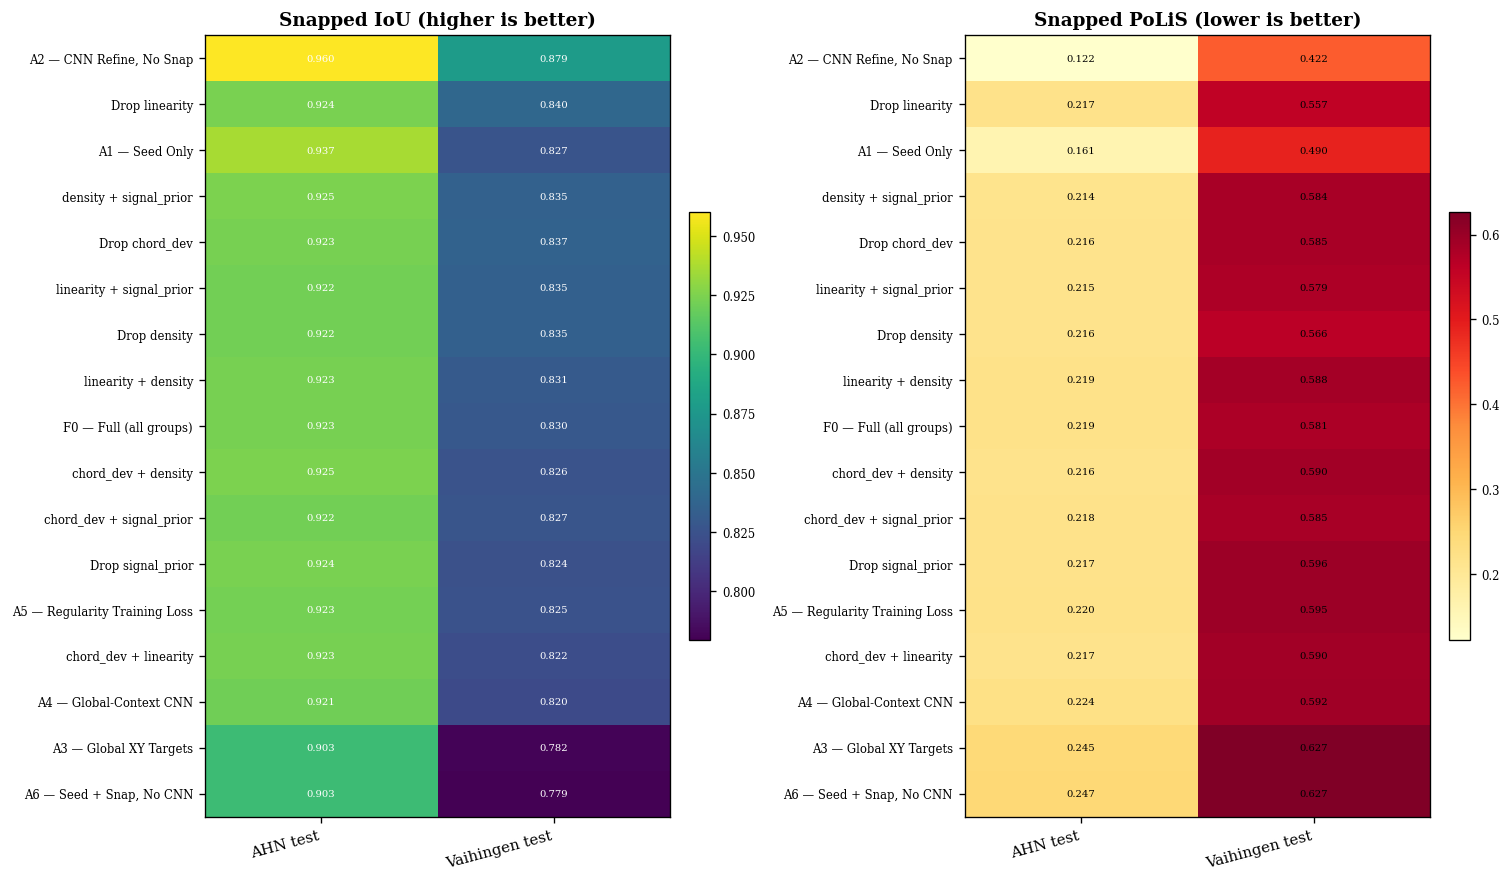

Saved: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\ahn_vaihingen_all_models_snapped_heatmaps.png
Saved: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\all_models_ahn_vaihingen_stagewise_metrics.csv
Saved: D:\Saqib\Footprint_Extraction\DIF\Code\outputs\seed_refine_snap_v9_with_vaihingen\all_models_ahn_vaihingen_snapped_metrics.csv


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL CROSS-DATASET TEST SUMMARY
# Runs every experiment once on AHN test data and Vaihingen test data.
# Produces tabular summaries, compact figures, and CSV exports.
# ─────────────────────────────────────────────────────────────────────────────
from IPython.display import display
def _collect_all_rows():
    rows = []
    if "feature_ablation_results" in globals() and feature_ablation_results:
        rows.extend(feature_ablation_results)
    if "component_ablation_results" in globals() and component_ablation_results:
        rows.extend(component_ablation_results)
    return rows
def _evaluate_row_on_dataset(row, pkl_dir, dataset_name):
    """
    Evaluate one experiment row on a dataset directory and return stage-wise aggregates.
    Works for both trained models and no-model baselines.
    """
    label = row.get("label", "experiment")
    model = row.get("model", None)
    stats = row.get("stats", None)
    feature_cols = row.get("cols", [])
    use_postproc = row.get("use_postproc", True)
    global_tgt = row.get("global_targets", False)
    if model is None:
        files = sorted(f for f in os.listdir(pkl_dir) if f.endswith(".pkl"))
        seed_results, refined_results, snapped_results = [], [], []
        for fname in files:
            try:
                with open(os.path.join(pkl_dir, fname), "rb") as f:
                    d = pickle.load(f)
                seed_pts = d["hull_points"].astype(np.float32)
                gt_pts = d["gt_points"].astype(np.float32)
                refined_pts = seed_pts
                snapped_pts = geometric_regularizer(seed_pts, **REG_CFG) if use_postproc else seed_pts
                m_seed = full_metrics(seed_pts, gt_pts)
                m_ref  = full_metrics(refined_pts, gt_pts)
                m_snap = full_metrics(snapped_pts, gt_pts)
                if m_seed is not None:
                    seed_results.append(m_seed)
                if m_ref is not None:
                    refined_results.append(m_ref)
                if m_snap is not None:
                    snapped_results.append(m_snap)
            except Exception:
                continue
        return {
            "seed": aggregate_metrics(seed_results),
            "refined": aggregate_metrics(refined_results),
            "snapped": aggregate_metrics(snapped_results),
        }
    agg, _ = compute_stage_metrics(
        model,
        pkl_dir,
        stats,
        feature_cols,
        global_targets=global_tgt,
        use_postproc=use_postproc,
        desc=f"{dataset_name} | {label}",
    )
    return agg
def _metric_row(dataset_name, exp_label, stage_name, metrics):
    return {
        "Dataset": dataset_name,
        "Experiment": exp_label,
        "Stage": stage_name,
        "IoU": metrics["iou"],
        "F1": metrics["f1"],
        "PoLiS (m)": metrics["polis"],
        "RMSE (m)": metrics["rmse"],
        "RCC (m)": metrics["rcc"],
    }
all_rows = _collect_all_rows()
if not all_rows:
    raise RuntimeError("No experiment rows found. Run the feature and component ablation cells first.")
datasets = [
    ("AHN test", CFG["test_out_dir"]),
    ("Vaihingen test", VAIHINGEN_PKL_DIR),
]
# Evaluate each experiment on each dataset only once.
dataset_cache = {}
summary_rows = []
for row in all_rows:
    exp_label = row.get("label", "experiment")
    for ds_name, ds_dir in datasets:
        cache_key = (exp_label, ds_name)
        if cache_key not in dataset_cache:
            dataset_cache[cache_key] = _evaluate_row_on_dataset(row, ds_dir, ds_name)
        agg = dataset_cache[cache_key]
        for stage_name in ["seed", "refined", "snapped"]:
            summary_rows.append(_metric_row(ds_name, exp_label, stage_name, agg[stage_name]))
summary_df = pd.DataFrame(summary_rows).copy()
summary_df = summary_df[[
    "Dataset", "Experiment", "Stage", "IoU", "F1", "PoLiS (m)", "RMSE (m)", "RCC (m)"
]].round(4)
# Final-stage table: one row per model, side-by-side for both datasets.
snapped_df = summary_df[summary_df["Stage"] == "snapped"].copy()
snap_pivot = snapped_df.pivot(
    index="Experiment",
    columns="Dataset",
    values=["IoU", "F1", "PoLiS (m)", "RMSE (m)", "RCC (m)"]
)
# Flatten and order columns for readability.
snap_pivot.columns = [f"{metric} | {dataset}" for metric, dataset in snap_pivot.columns]
snap_pivot = snap_pivot.reset_index()
# Sort by mean snapped IoU across both datasets.
iou_cols = [c for c in snap_pivot.columns if c.startswith("IoU | ")]
snap_pivot["_mean_iou"] = snap_pivot[iou_cols].mean(axis=1)
snap_pivot = snap_pivot.sort_values("_mean_iou", ascending=False).drop(columns="_mean_iou")
snap_pivot = snap_pivot.round(4)
# Full model stage-wise comparison table (small, focused, easy to read).
def _full_model_row(rows):
    for r in rows:
        label = str(r.get("label", "")).lower()
        if label.startswith("f0") or "full" in label:
            return r
    return rows[0]
full_row = _full_model_row(all_rows)
full_stage_rows = []
for ds_name, ds_dir in datasets:
    agg = dataset_cache[(full_row.get("label", "experiment"), ds_name)]
    for stage_name in ["seed", "refined", "snapped"]:
        m = agg[stage_name]
        full_stage_rows.append({
            "Dataset": ds_name,
            "Stage": stage_name,
            "IoU": m["iou"],
            "F1": m["f1"],
            "PoLiS (m)": m["polis"],
            "RMSE (m)": m["rmse"],
            "RCC (m)": m["rcc"],
        })
full_stage_df = pd.DataFrame(full_stage_rows).round(4)
print("\n" + "="*110)
print("ALL MODELS — SNAPSHOTTED FINAL TEST METRICS (AHN + VAIHINGEN)")
print("="*110)
display(snap_pivot)
print("\n" + "="*110)
print("FULL MODEL — STAGE-WISE TEST METRICS ON BOTH DATASETS")
print("="*110)
display(full_stage_df)
# Compact, all-model visual summary: two heatmaps (IoU and PoLiS) across both datasets.
heat_df_iou = snapped_df.pivot(index="Experiment", columns="Dataset", values="IoU")
heat_df_polis = snapped_df.pivot(index="Experiment", columns="Dataset", values="PoLiS (m)")
# Sort rows by mean IoU to keep the figure readable.
order = heat_df_iou.mean(axis=1).sort_values(ascending=False).index
heat_df_iou = heat_df_iou.loc[order]
heat_df_polis = heat_df_polis.loc[order]
fig, axes = plt.subplots(1, 2, figsize=(12.5, max(5.5, 0.32 * len(order) + 1.8)), constrained_layout=True)
def _annotated_heatmap(ax, df, title, fmt="{:.3f}", cmap="viridis", invert_y=False):
    vals = df.to_numpy(dtype=float)
    im = ax.imshow(vals, aspect="auto", cmap=cmap)
    ax.set_xticks(range(df.shape[1]))
    ax.set_xticklabels(df.columns, rotation=15, ha="right")
    ax.set_yticks(range(df.shape[0]))
    ax.set_yticklabels(df.index, fontsize=7)
    ax.set_title(title, fontweight="bold")
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            v = vals[i, j]
            if np.isfinite(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=6, color="white" if cmap != "YlOrRd" else "black")
    return im
im1 = _annotated_heatmap(axes[0], heat_df_iou, "Snapped IoU (higher is better)", fmt="{:.3f}", cmap="viridis")
im2 = _annotated_heatmap(axes[1], heat_df_polis, "Snapped PoLiS (lower is better)", fmt="{:.3f}", cmap="YlOrRd")
cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar1.ax.tick_params(labelsize=7)
cbar2.ax.tick_params(labelsize=7)
out_png = os.path.join(OUTPUT_DIR, "ahn_vaihingen_all_models_snapped_heatmaps.png")
plt.savefig(out_png, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")
# CSV exports for downstream analysis.
all_csv = os.path.join(OUTPUT_DIR, "all_models_ahn_vaihingen_stagewise_metrics.csv")
snap_csv = os.path.join(OUTPUT_DIR, "all_models_ahn_vaihingen_snapped_metrics.csv")
summary_df.to_csv(all_csv, index=False)
snap_pivot.to_csv(snap_csv, index=False)
print(f"Saved: {all_csv}")
print(f"Saved: {snap_csv}")


Using experiment: F0 — Full (all groups)
Feature cols: [0, 1, 2, 3]
global_targets=False | use_postproc=True

AHN3 test | random_state=2


,building_id,seed_IoU,seed_F1,refined_IoU,refined_F1,snapped_IoU,snapped_F1,snapped_PoLiS,snapped_RMSE,snapped_RCC
0,building_277,0.9428,0.9705,0.9750,0.9874,0.9043,0.9498,0.2011,0.2040,0.3878
1,building_316,0.9420,0.9701,0.9628,0.9810,0.9563,0.9776,0.0970,0.1084,0.6078
2,building_199,0.9494,0.9740,0.9766,0.9882,0.8781,0.9351,0.3364,0.2620,0.9945
3,building_269,0.9143,0.9552,0.9618,0.9805,0.9694,0.9845,0.0605,0.0442,0.5773
4,building_204,0.9415,0.9699,0.9732,0.9864,0.9614,0.9803,0.1282,0.0825,0.2015


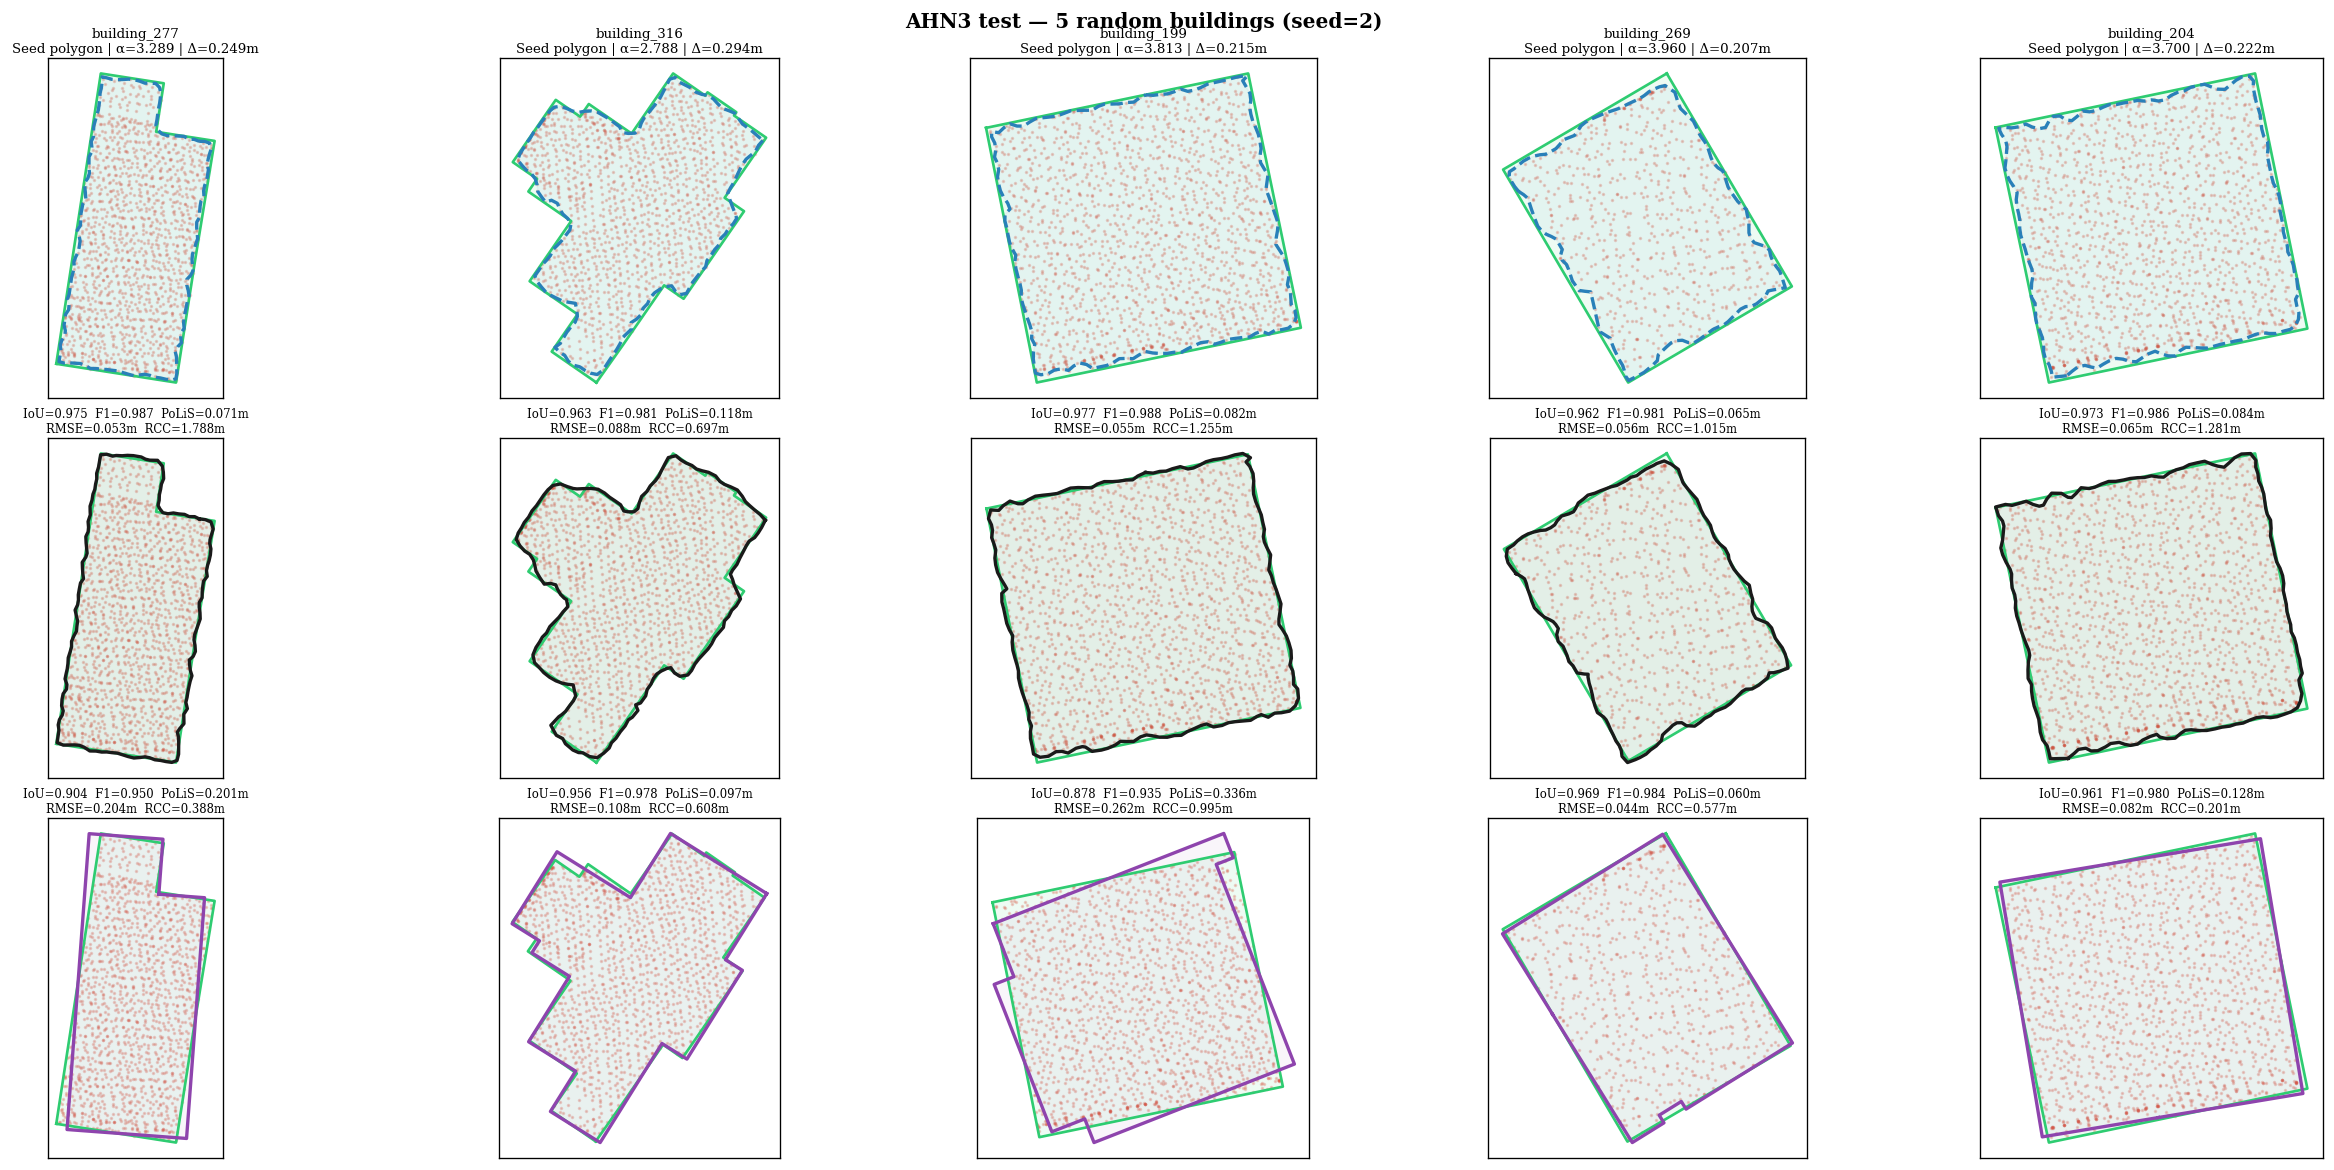


Vaihingen test | random_state=2


,building_id,seed_IoU,seed_F1,refined_IoU,refined_F1,snapped_IoU,snapped_F1,snapped_PoLiS,snapped_RMSE,snapped_RCC
0,building_015,0.7006,0.8240,0.8436,0.9152,0.7416,0.8516,0.3794,0.2857,0.7285
1,building_014,0.9266,0.9619,0.9588,0.9790,0.9503,0.9745,0.1473,0.1601,1.8945
2,building_022,0.9405,0.9694,0.9656,0.9825,0.7823,0.8778,1.1139,0.9915,2.8488
3,building_003,0.9629,0.9811,0.9794,0.9896,0.8862,0.9396,0.9647,0.9986,1.6934
4,building_099,0.9092,0.9524,0.9326,0.9651,0.9208,0.9587,0.3889,0.6940,0.9077


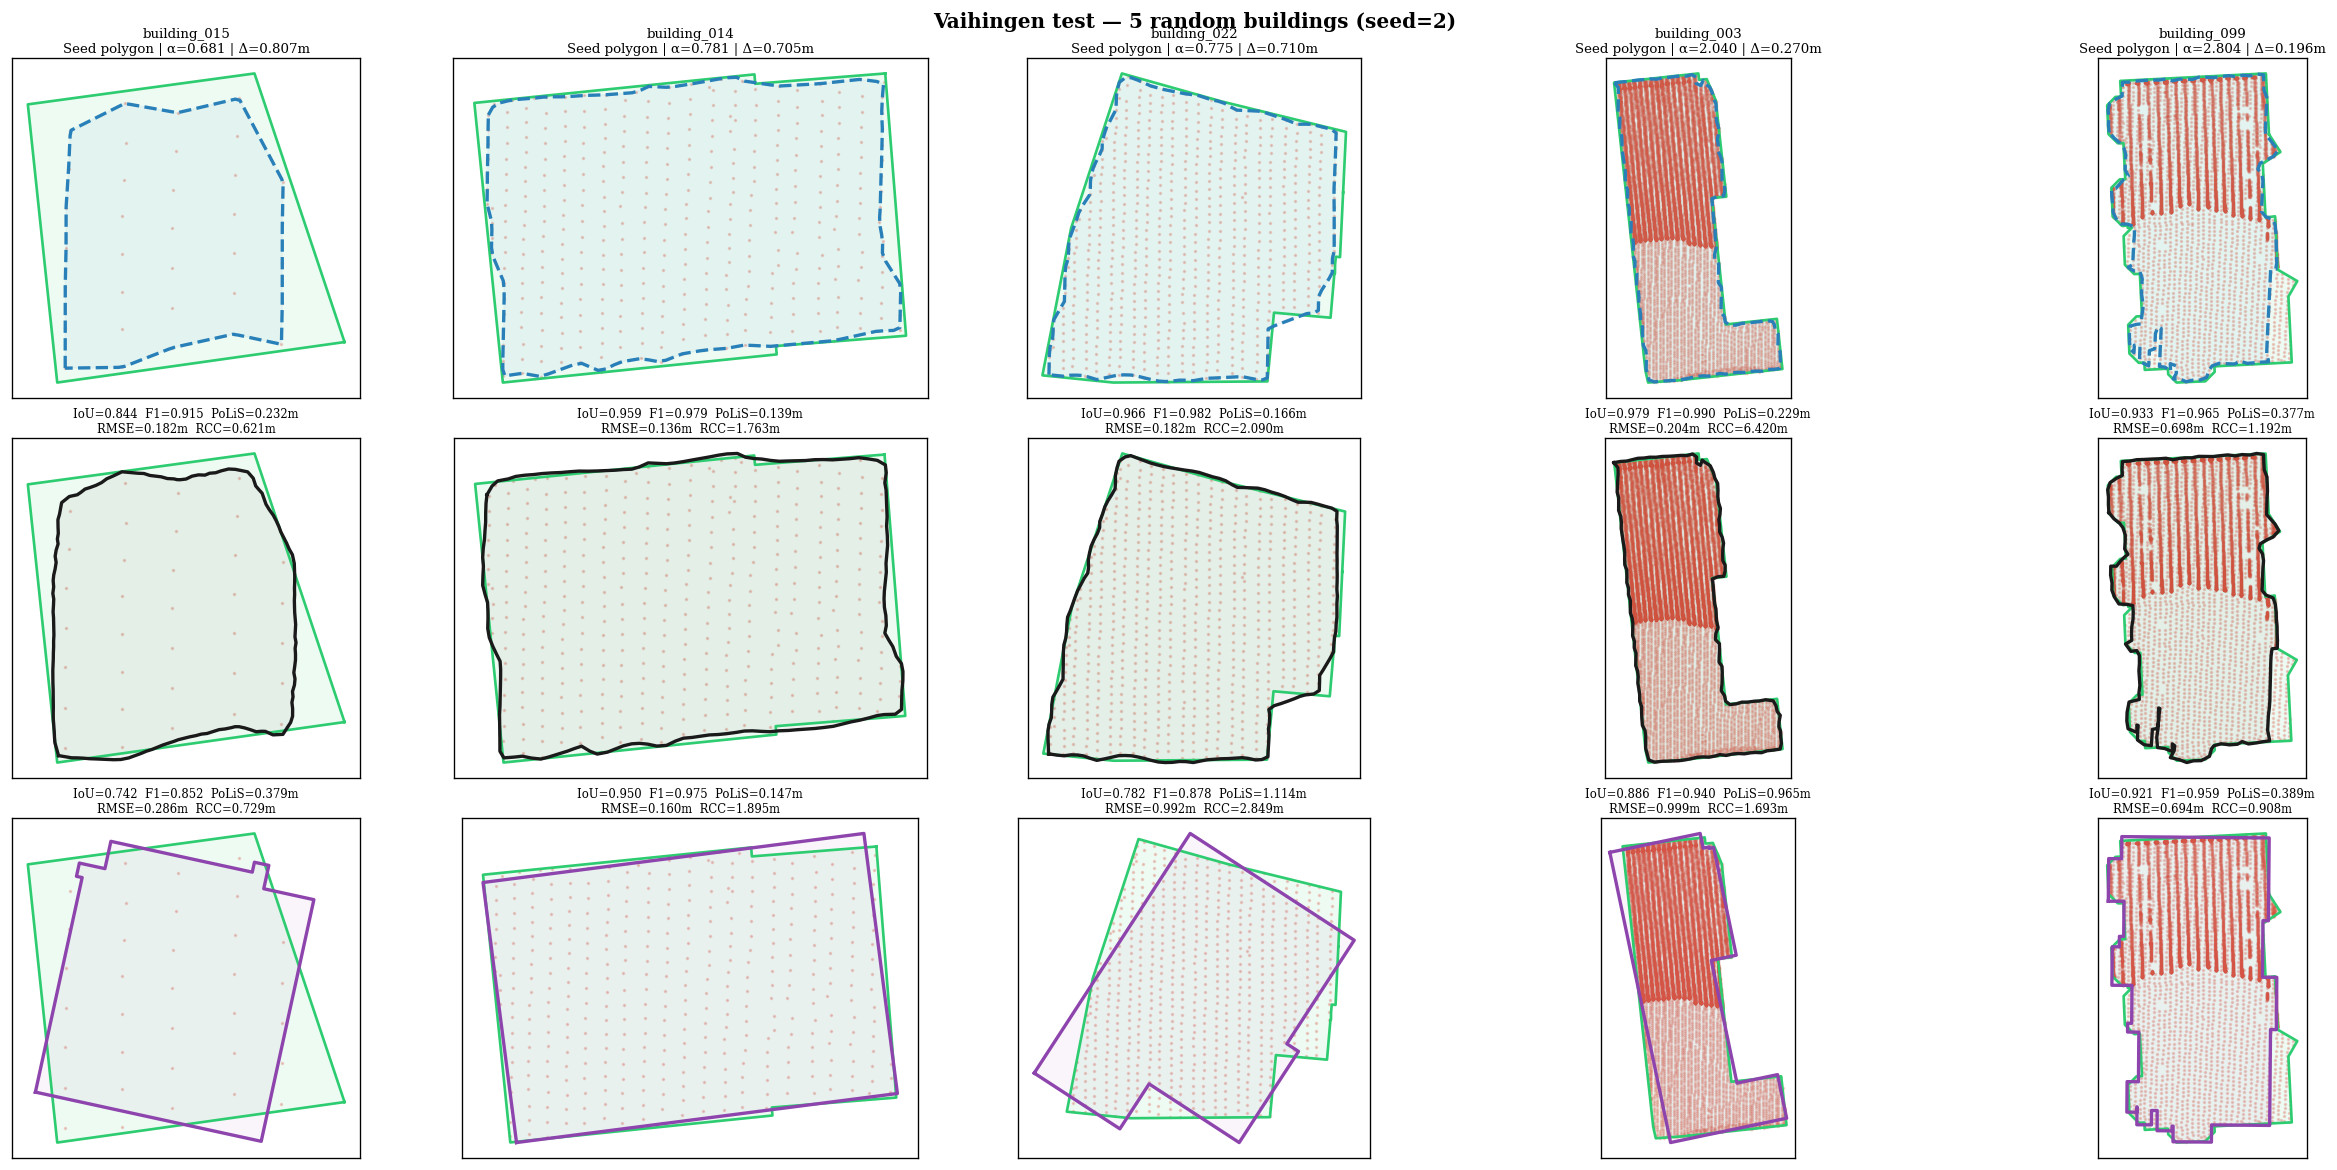

In [20]:
# Reproducible qualitative audit: 5 random buildings from AHN3 and 5 from Vaihingen
AHN3_RANDOM_STATE = 2
VAIHINGEN_RANDOM_STATE = 2
N_SAMPLES = 5
def _pick_reference_row():
    rows = []
    for name in ("component_ablation_results", "feature_ablation_results"):
        if name in globals() and globals()[name]:
            rows.extend(globals()[name])
    if not rows:
        raise RuntimeError("No experiment results found. Run the training / ablation cells first.")
    # Prefer the full model if it exists.
    for r in rows:
        label = str(r.get("label", "")).lower()
        if label.startswith("f0") or "full (all groups)" in label:
            return r
    # Otherwise use the best available trained row.
    trained = [r for r in rows if r.get("model") is not None]
    if not trained:
        raise RuntimeError("No in-memory model found in the experiment rows.")
    return min(trained, key=lambda r: r.get("val_loss", float("inf")))
row = _pick_reference_row()
feature_cols = row["cols"]
global_targets = row.get("global_targets", False)
use_postproc = row.get("use_postproc", True)
model_type = row.get("model_type", "local")
model = row.get("model", None)
stats = row.get("stats", None)
if model is None:
    if "ckpt_path" not in row:
        raise RuntimeError("No model in memory and no checkpoint path available.")
    model, _ = _load_model_from_checkpoint(row["ckpt_path"], len(feature_cols), model_type=model_type)
if stats is None:
    if "stats_path" not in row:
        raise RuntimeError("No stats in memory and no stats path available.")
    stats, _ = load_norm_stats(
        row["stats_path"],
        fallback_data_dir=CFG["train_out_dir"],
        feature_cols=feature_cols,
        use_global_targets=global_targets,
    )
print(f"Using experiment: {row.get('label', 'experiment')}")
print(f"Feature cols: {feature_cols}")
print(f"global_targets={global_targets} | use_postproc={use_postproc}")
def _show_random_audit(pkl_dir, dataset_name, seed):
    samples = vis_samples(
        model,
        stats,
        feature_cols,
        global_targets=global_targets,
        use_postproc=use_postproc,
        n=N_SAMPLES,
        seed=seed,
        pkl_dir=pkl_dir,
    )
    if not samples:
        print(f"{dataset_name}: no valid samples found.")
        return
    summary = pd.DataFrame([
        {
            "building_id": s["bid"],
            "seed_IoU": None if s["metrics_seed"] is None else s["metrics_seed"]["iou"],
            "seed_F1": None if s["metrics_seed"] is None else s["metrics_seed"]["f1"],
            "refined_IoU": None if s["metrics_ref"] is None else s["metrics_ref"]["iou"],
            "refined_F1": None if s["metrics_ref"] is None else s["metrics_ref"]["f1"],
            "snapped_IoU": None if s["metrics_snap"] is None else s["metrics_snap"]["iou"],
            "snapped_F1": None if s["metrics_snap"] is None else s["metrics_snap"]["f1"],
            "snapped_PoLiS": None if s["metrics_snap"] is None else s["metrics_snap"]["polis"],
            "snapped_RMSE": None if s["metrics_snap"] is None else s["metrics_snap"]["rmse"],
            "snapped_RCC": None if s["metrics_snap"] is None else s["metrics_snap"]["rcc"],
        }
        for s in samples
    ])
    print(f"\n{dataset_name} | random_state={seed}")
    display(summary.round(4))
    plot_buildings(samples, f"{dataset_name} — 5 random buildings (seed={seed})", n_show=N_SAMPLES)
_show_random_audit(CFG["test_out_dir"], "AHN3 test", AHN3_RANDOM_STATE)
_show_random_audit(VAIHINGEN_PKL_DIR, "Vaihingen test", VAIHINGEN_RANDOM_STATE)